# WastePilot: Proof of Concept
### Korrelation von Umweltdaten und Abfallmengen als Grundlage für tagesaktuelle Prognosen

**Modul:** BBCS FS26 &nbsp; **Gruppe:** 19

These: Wetterdaten, Luftqualität und Events korrelieren messbar mit dem täglichen Abfallaufkommen pro Stadtkreis.

Hinweis Wetter-Alternativen: Als primäre Wetterdatenquelle wird Open-Meteo verwendet.

Hinweis Abfalldaten: Tägliche Abfallmengen pro Stadtkreis existieren nicht als Open Data.

Hinweis Events-API: Die Tourismus-API liefert GPS-Koordinaten.

---

### Einsatz von KI-Werkzeugen

Im Rahmen dieses PoC wurden KI-Tools (ChatGPT und Claude) unterstützend eingesetzt, insbesondere für:
- die strukturierte Kommentierung des Codes (didaktische Erklärungen pro Schritt),
- die Validierung der Gewichtungsfaktoren (z. B. Eurostat-, BAFU- und ERZ-Quellen),
- die sprachliche Überarbeitung der Markdown-Texte.

Alle inhaltlichen Entscheidungen (Datenquellen, Modellwahl, Gewichtungslogik, Risikoampel, Empfehlungslogik) sowie die Architektur der Pipeline wurden durch die Gruppe selbst getroffen und überprüft.


## 1. Setup und Imports

Bevor wir starten, müssen die benötigten Python-Bibliotheken installiert sein. Falls eine davon im System fehlt, lässt sie sich mit folgendem Befehl nachinstallieren:

```
pip install pandas numpy matplotlib seaborn scikit-learn requests folium
```

In der nächsten Code-Zelle importieren wir alle Bibliotheken und definieren die Stammdaten für die zwölf Stadtkreise: Einwohnerzahlen, Bounding Boxes für die GPS-Zuordnung und die deutschen Anzeigenamen mit Umlauten.


In [1]:
# Alle benötigten Bibliotheken importieren und grundlegende Konfiguration (Farben, Stadtkreis-Daten) festlegen.


# --- Schritt 1: Bibliotheken importieren ---

# pandas (pd): Bibliothek für Datentabellen (DataFrames)
import pandas as pd

# numpy (np): Bibliothek für Zahlenberechnungen und Arrays (Zahlenlisten)
import numpy as np

# matplotlib.pyplot (plt): Bibliothek zum Erstellen von Diagrammen und Grafiken
import matplotlib.pyplot as plt

# matplotlib.dates (mdates): Hilfsmodul für Datumsachsen in Diagrammen
import matplotlib.dates as mdates

# seaborn (sns): Aufbau auf matplotlib, einfacher für statistische Grafiken (z.B. Heatmap)
import seaborn as sns

# requests: Bibliothek für HTTP-Anfragen (URLs aufrufen, APIs abfragen)
# json: Eingebautes Modul zum Lesen/Schreiben von JSON-Dateien
# warnings: Eingebautes Modul zum Unterdrücken von Warnmeldungen
import requests, json, warnings

# datetime: Klasse für Datumsobjekte (z.B. "heute minus 5 Tage" berechnen)
# timedelta: Klasse für Zeitdifferenzen (z.B. timedelta(days=5) = 5 Tage)
from datetime import datetime, timedelta

# RandomForestRegressor: Das ML-Modell – "Random Forest" für Zahlenwerte (Regression)
# Mehr dazu in Zelle 10 / Schritt 10
from sklearn.ensemble import RandomForestRegressor

# cross_val_score: Kreuzvalidierung – prüft wie gut das Modell auf ungesehenen Daten ist
from sklearn.model_selection import cross_val_score

# Fehlermetriken: Wie weit liegt die Prognose daneben?
# mean_absolute_error (MAE): durchschnittlicher absoluter Fehler
# mean_squared_error (MSE): quadratischer Fehler (bestraft grosse Fehler stärker)
# r2_score (R²): Wie viel Prozent der Schwankung erklärt das Modell?
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Warnungen ausblenden (z.B. Pandas-Deprecation-Warnings) – für saubere Ausgabe
warnings.filterwarnings('ignore')


# --- Schritt 2: Matplotlib-Standardwerte konfigurieren ---
# rcParams = "runtime configuration parameters" – globale Einstellungen für alle Grafiken

# Standardgrösse aller Grafiken: 13 Zoll breit, 5 Zoll hoch (~33 x 12.7 cm)
# Matplotlib verwendet Zoll, nicht Zentimeter
plt.rcParams['figure.figsize'] = (13, 5)

# Obere und rechte Achsenrahmen ausblenden (modernes, cleanes Design)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


# --- Schritt 3: Farbpalette definieren ---
# Dictionary: Schlüssel = Farbname (str), Wert = Hex-Farbcode (str)
# Hex-Farbcodes: '#RRGGBB' – 6 Hexadezimalzahlen für Rot, Grün, Blau
COLORS = {
    'grün': '#1D9E75',   # Grün  – für "gut" / positiv
    'blau':  '#185FA5',   # Blau  – neutrale Daten
    'rot':   '#E24B4A',   # Rot   – für "hoch" / Warnung
    'gelb':  '#EF9F27',   # Gelb  – für "mittel"
    'grau':  '#888780',   # Grau  – für Referenzlinien / Hintergrund
}


# --- Schritt 4: Stadtkreis-Stammdaten ---
# Alle 12 Stadtkreise Zürich
# Einwohnerzahlen: Statistik Stadt Zürich 2025 (≈ 452 421 gesamt)
# Quelle: data.stadt-zuerich.ch – bev_bestand_jahr_kreis_od3242
#
# basis_t: Basis-Tonnen Abfall/Tag, proportional zu Einwohnerzahl + Gewerbefaktor
#           -> Oerlikon (Kreis 11, 80 964 EW) hat basis_t=7.4 (viel Abfall)
#           -> Altstadt (Kreis 1, 5 747 EW) hat basis_t=0.9 (wenig Einwohner, aber Gewerbe)
#
# event_p: Wahrscheinlichkeit eines Events pro Tag im Stadtkreis (0.0 bis 1.0)
#           -> 0.15 = 15% Chance, dass an einem zufälligen Tag ein Event stattfindet

# Dictionary of Dictionaries: STADTKREISE['Altstadt'] = {'basis_t': 0.9, 'event_p': 0.15}
STADTKREISE = {
    'Altstadt':       {'basis_t': 0.9, 'event_p': 0.15},  # Kreis 1  –   5 747 EW, hoher Gewerbefaktor
    'Wollishofen':    {'basis_t': 3.5, 'event_p': 0.06},  # Kreis 2  –  38 360 EW
    'Wiedikon':       {'basis_t': 4.7, 'event_p': 0.06},  # Kreis 3  –  51 608 EW
    'Aussersihl':     {'basis_t': 2.9, 'event_p': 0.09},  # Kreis 4  –  29 380 EW, Langstrasse
    'Escher Wyss':    {'basis_t': 1.9, 'event_p': 0.05},  # Kreis 5  –  15 954 EW, Industriequartier
    'Unterstrass':    {'basis_t': 3.4, 'event_p': 0.06},  # Kreis 6  –  36 584 EW
    'Hottingen':      {'basis_t': 3.7, 'event_p': 0.05},  # Kreis 7  –  40 152 EW
    'Riesbach':       {'basis_t': 2.2, 'event_p': 0.07},  # Kreis 8  –  17 936 EW, Seefeld/Tourismus
    'Altstetten':     {'basis_t': 5.6, 'event_p': 0.08},  # Kreis 9  –  61 178 EW, grösster Kreis nach Fläche
    'Hoengg':         {'basis_t': 3.8, 'event_p': 0.04},  # Kreis 10 –  41 726 EW, Höngg + Wipkingen
    'Oerlikon':       {'basis_t': 7.4, 'event_p': 0.07},  # Kreis 11 –  80 964 EW, bevölkerungsreichster Kreis (EW)
    'Schwamendingen': {'basis_t': 3.0, 'event_p': 0.04},  # Kreis 12 –  32 832 EW
}


# --- Schritt 5: Bounding Boxes für GPS -> Stadtkreis-Zuordnung ---
# Eine Bounding Box ist ein Rechteck, definiert durch 4 GPS-Koordinaten: (lon_min, lon_max, lat_min, lat_max) -> lon = Längengrad (West-Ost), lat = Breitengrad (Nord-Süd)
# Wenn ein GPS-Punkt innerhalb des Rechtecks liegt -> Stadtkreis gefunden
STADTKREIS_BBOX = {
    'Altstadt':       (8.527, 8.556, 47.368, 47.385),
    'Wollishofen':    (8.507, 8.565, 47.329, 47.368),
    'Wiedikon':       (8.493, 8.528, 47.348, 47.384),
    'Aussersihl':     (8.514, 8.543, 47.374, 47.396),
    'Escher Wyss':    (8.503, 8.536, 47.384, 47.406),
    'Unterstrass':    (8.528, 8.575, 47.387, 47.416),
    'Hottingen':      (8.549, 8.622, 47.349, 47.408),
    'Riesbach':       (8.537, 8.580, 47.344, 47.372),
    'Altstetten':     (8.453, 8.502, 47.364, 47.416),
    'Hoengg':         (8.472, 8.534, 47.384, 47.430),
    'Oerlikon':       (8.517, 8.601, 47.404, 47.448),
    'Schwamendingen': (8.550, 8.626, 47.390, 47.432),
}


# --- Schritt 6: Mittelpunkte der Stadtkreise (für Karten-Visualisierung) ---
# Jeder Stadtkreis hat einen "Mittelpunkt" (lat, lon) für Marker auf der Karte
STADTKREIS_ZENTRUM = {
    'Altstadt':       (47.374, 8.540),
    'Wollishofen':    (47.348, 8.535),
    'Wiedikon':       (47.367, 8.512),
    'Aussersihl':     (47.382, 8.526),
    'Escher Wyss':    (47.393, 8.518),
    'Unterstrass':    (47.399, 8.550),
    'Hottingen':      (47.378, 8.575),
    'Riesbach':       (47.357, 8.557),
    'Altstetten':     (47.390, 8.476),
    'Hoengg':         (47.406, 8.503),
    'Oerlikon':       (47.422, 8.549),
    'Schwamendingen': (47.408, 8.587),
}


# --- Schritt 7: Anzeigenamen mit Umlauten ---
# Intern arbeiten wir mit einfachen ASCII-Schlüsseln ('Hoengg', 'Altstadt')
# Für die Anzeige (Karte, Ausgabe) brauchen wir die schönen Namen mit Umlauten und der Kreiszahl. Dieses Dictionary macht die Übersetzung.
STADTKREIS_ANZEIGE = {
    'Altstadt':       'Altstadt (Kr. 1)',
    'Wollishofen':    'Wollishofen (Kr. 2)',
    'Wiedikon':       'Wiedikon (Kr. 3)',
    'Aussersihl':     'Aussersihl (Kr. 4)',
    'Escher Wyss':    'Escher Wyss (Kr. 5)',
    'Unterstrass':    'Unterstrass (Kr. 6)',
    'Hottingen':      'Hottingen (Kr. 7)',
    'Riesbach':       'Riesbach (Kr. 8)',
    'Altstetten':     'Altstetten (Kr. 9)',
    'Hoengg':         'Höngg (Kr. 10)',
    'Oerlikon':       'Oerlikon (Kr. 11)',
    'Schwamendingen': 'Schwamendingen (Kr. 12)',
}

# len(STADTKREISE) gibt die Anzahl Einträge im Dictionary zurück = 12
print(f'OK Setup abgeschlossen – {len(STADTKREISE)} Stadtkreise konfiguriert')
print(f'  Einwohnerzahlen: Statistik Stadt Zürich 2025 (ca. 452 421 gesamt)')
print(f'  Quelle: data.stadt-zuerich.ch – bev_bestand_jahr_kreis_od3242')


OK Setup abgeschlossen – 12 Stadtkreise konfiguriert
  Einwohnerzahlen: Statistik Stadt Zürich 2025 (ca. 452 421 gesamt)
  Quelle: data.stadt-zuerich.ch – bev_bestand_jahr_kreis_od3242


---
## 2. Wetterdaten: Open-Meteo API

Als erste Datenquelle binden wir das Wetter ein. Wir nutzen dafür [open-meteo.com](https://open-meteo.com/), weil dieser Dienst die Rohdaten von MeteoSchweiz aufbereitet zur Verfügung stellt, kostenlos ist und keinen API-Key benötigt. Konkret sprechen wir den Endpunkt `https://archive-api.open-meteo.com/v1/archive` an, der uns historische Werte für die letzten 90 Tage zurückliefert.

Die URL-Parameter funktionieren im Prinzip wie eine SELECT-Abfrage in SQL. Anstatt einer Datenbankabfrage hängen wir die gewünschten Felder und den Zeitraum an die URL an:

```sql
SELECT temperature_2m_max, precipitation_sum, windspeed_10m_max
FROM wetterdaten
WHERE latitude=47.38 AND longitude=8.54
  AND datum BETWEEN :start AND :end
```

Wir haben uns überlegt, ob wir stattdessen das offizielle Dataset [ugz_meteodaten_tagesmittelwerte](https://data.stadt-zuerich.ch/dataset/ugz_meteodaten_tagesmittelwerte) der Stadt Zürich verwenden sollen. Beim Vergleich der beiden Quellen sind uns aber mehrere Einschränkungen aufgefallen:

| Parameter | Stadt Zürich Meteodaten | Open-Meteo |
|-----------|--------------------------|------------|
| Temperatur | `T` in °C | `temperature_2m_max` in °C |
| Niederschlag | nur `RainDur` (Dauer in **Minuten**, kein Betrag in mm) | `precipitation_sum` in **mm** |
| Wind | **nicht verfügbar** | `windspeed_10m_max` in km/h |
| Sonnenstrahlung | `StrGlo` in W/m² | nicht im Archiv-Endpunkt |

Da uns die Niederschlagsmenge in mm und die Windgeschwindigkeit fehlen würden und der Regen in einer anderen Einheit (Minuten statt Millimeter) geliefert wird, wäre der Datensatz für unsere Auswertung inkonsistent. Damit alle Wetterparameter in einheitlichen Einheiten vorliegen, haben wir uns für Open-Meteo als einzige Wetterquelle entschieden.

### Zum Beachten

* Wir verwenden bewusst die `archive-api` und nicht die normale API. Die Archiv-API liefert historische Daten der vergangenen 90 Tage; daneben gibt es noch eine Echtzeit- und eine Prognose-API, die wir später für den 7-Tage-Forecast einsetzen.
* Alles hinter dem `?` in einer URL sind Parameter. Beispiel: `?latitude=47.38&longitude=8.54` heisst "Daten für diese GPS-Position bitte". Mehrere Parameter werden mit `&` getrennt.


In [2]:
# Zwei Funktionen für Wetterdaten:
# 1. wetter_abrufen(): Echte Daten von Open-Meteo API holen
# 2. _wetter_fallback(): Synthetische Daten falls API nicht erreichbar
# Dann: wetter_df = die eigentlichen Wetterdaten (90 Tage)


# --- Funktion definieren: Wetterdaten von API abrufen ---
# Parameter mit Standardwerten: lat=47.38 (Breitengrad Zürich), lon=8.54 (Längengrad Zürich), tage=90 (wie viele Tage zurück)
# Wenn man wetter_abrufen() aufruft ohne Argumente, nimmt Python diese Standardwerte
def wetter_abrufen(lat=47.38, lon=8.54, tage=90):
    '''
    Wetterdaten der letzten `tage` Tage von Open-Meteo abrufen.
    Open-Meteo gibt erst nach 5 Tagen Daten frei, daher end = heute - 5.

    Eingabe: lat (float) = Breitengrad, lon (float) = Längengrad, tage (int) = Anzahl Tage
    Ausgabe: pandas DataFrame mit Spalten: datum, temperatur, niederschlag, windgeschw
    '''
    # Enddatum = heute minus 5 Tage (Open-Meteo hat 5 Tage Verzögerung)
    # datetime.today(): gibt das heutige Datum+Zeit zurück
    # timedelta(days=5): Zeitdifferenz von 5 Tagen
    # .strftime('%Y-%m-%d'): formatiert Datum als String "YYYY-MM-DD" (ISO-Format)
    end = (datetime.today() - timedelta(days=5)).strftime('%Y-%m-%d')

    # Startdatum = heute minus (tage + 5) Tage
    start = (datetime.today() - timedelta(days=tage+5)).strftime('%Y-%m-%d')

    # URL zusammenbauen – f-String mit mehreren Zeilen (Klammer erlaubt Zeilenumbruch)
    # Jede Zeile wird zusammengehängt (kein Leerzeichen dazwischen, deshalb & am Anfang)
    url = (
        f'https://archive-api.open-meteo.com/v1/archive'
        f'?latitude={lat}&longitude={lon}'
        f'&start_date={start}&end_date={end}'
        f'&daily=temperature_2m_max,precipitation_sum,windspeed_10m_max'
        f'&timezone=Europe/Zurich'
    )

    # try/except: "Versuche X, und wenn ein Fehler passiert, mach Y stattdessen" -> Das schützt vor Abstürzen wenn die API nicht erreichbar ist
    try:
        # requests.get(): sendet eine HTTP GET-Anfrage an die URL
        # timeout=10: nach 10 Sekunden aufgeben (sonst wartet Python ewig)
        r = requests.get(url, timeout=10)

        # raise_for_status(): wenn der HTTP-Statuscode ein Fehler ist (z.B. 404, 500),
        # wird eine Exception ausgelöst -> springt direkt in den except-Block
        r.raise_for_status()

        # r.json(): verarbeitet die JSON-Antwort als Python-Dictionary
        # ['daily']: nimmt den 'daily'-Schlüssel aus dem Dictionary
        d = r.json()['daily']

        # pd.DataFrame({...}): erstellt eine Tabelle aus einem Dictionary
        # Jeder Schlüssel wird eine Spalte, der Wert ist die Liste der Zeilenwerte
        df = pd.DataFrame({
            'datum':        pd.to_datetime(d['time']), # String -> Datumsobjekt
            'temperatur':   d['temperature_2m_max'], # Tageshöchsttemperatur in °C
            'niederschlag': d['precipitation_sum'], # Niederschlag in mm
            'windgeschw':   d['windspeed_10m_max'], # Windgeschwindigkeit in km/h
        })

        # .ffill() = "forward fill": Fehlende Werte (NaN) mit dem letzten gültigen Wert füllen -> Beispiel: [1.2, NaN, NaN, 3.4] -> [1.2, 1.2, 1.2, 3.4]
        # NaN = "Not a Number" – Platzhalter für fehlende Werte in pandas
        df = df.ffill()

        # Kontrollausgabe: Anzahl geladener Tage
        print(f'OK Open-Meteo: {len(df)} Tage ({start} – {end})')
        return df

    except Exception as e:
        # Exception e enthält die Fehlermeldung
        print(f'WARNUNG: Open-Meteo: {e} -> Fallback')
        # Fallback-Funktion aufrufen (synthetische Daten)
        return _wetter_fallback(tage)


# --- Fallback-Funktion: Synthetische Wetterdaten ---
# Der Unterstrich am Anfang (_wetter_fallback) ist Python-Konvention für "private" Funktion – nur intern verwendet, nicht von aussen aufrufen
def _wetter_fallback(tage=90):
    '''Synthetische Wetterdaten mit saisonalem Muster als Fallback.

    Ausgabe: pandas DataFrame mit gleicher Struktur wie wetter_abrufen()
    '''
    # Zufallsgenerator mit festem Startwert (seed=42) damit immer gleiche Zufallszahlen -> Reproduzierbarkeit: jedes Mal gleiche synthetische Daten
    np.random.seed(42)

    # pd.date_range(): erzeugt eine Folge von Datumswerten
    # end = heute minus 5 Tage, periods = Anzahl Tage, freq='D' = täglich
    daten = pd.date_range(end=datetime.today() - timedelta(days=5), periods=tage, freq='D')

    # Tagesnummer im Jahr (1–365) für jeden Tag berechnen
    # timetuple().tm_yday = "day of year"
    t = np.array([d.timetuple().tm_yday for d in daten])

    # Temperatur mit sinusförmigem Jahresmuster: 10°C Basistemperatur + ±10°C saisonale Schwankung + Zufallsrauschen
    # np.sin(2π * (t-80) / 365): Sinuskurve mit Jahresperiode, Nullpunkt verschoben
    # np.random.normal(0, 3, tage): normalverteiltes Rauschen, Mittelwert=0, Std=3°C
    temp  = 10 + 10 * np.sin((t - 80) * 2 * np.pi / 365) + np.random.normal(0, 3, tage)

    # Regen: Exponentialverteilung (viele kleine, wenige grosse Werte)
    regen = np.random.exponential(2, tage)

    # 65% der Tage kein Regen (np.random.rand(tage) > 0.35)
    # np.random.rand: gleichmässig verteilte Zufallszahlen zwischen 0 und 1
    regen[np.random.rand(tage) > 0.35] = 0

    return pd.DataFrame({
        'datum':        daten,
        'temperatur':   temp.round(1), # runden auf 1 Dezimalstelle
        'niederschlag': regen.round(1),
        'windgeschw':   np.random.uniform(5, 30, tage).round(1), # gleichmässig zwischen 5-30 km/h
    })


# Funktion aufrufen und Ergebnis in Variable speichern
wetter_df = wetter_abrufen()

# .head(3): zeigt die ersten 3 Zeilen der Tabelle (zur Kontrolle)
wetter_df.head(3)


OK Open-Meteo: 91 Tage (2026-02-12 – 2026-05-13)


,datum,temperatur,niederschlag,windgeschw
0,2026-02-12,6.9,16.0,30.8
1,2026-02-13,10.3,0.4,22.3
2,2026-02-14,6.1,6.5,16.1


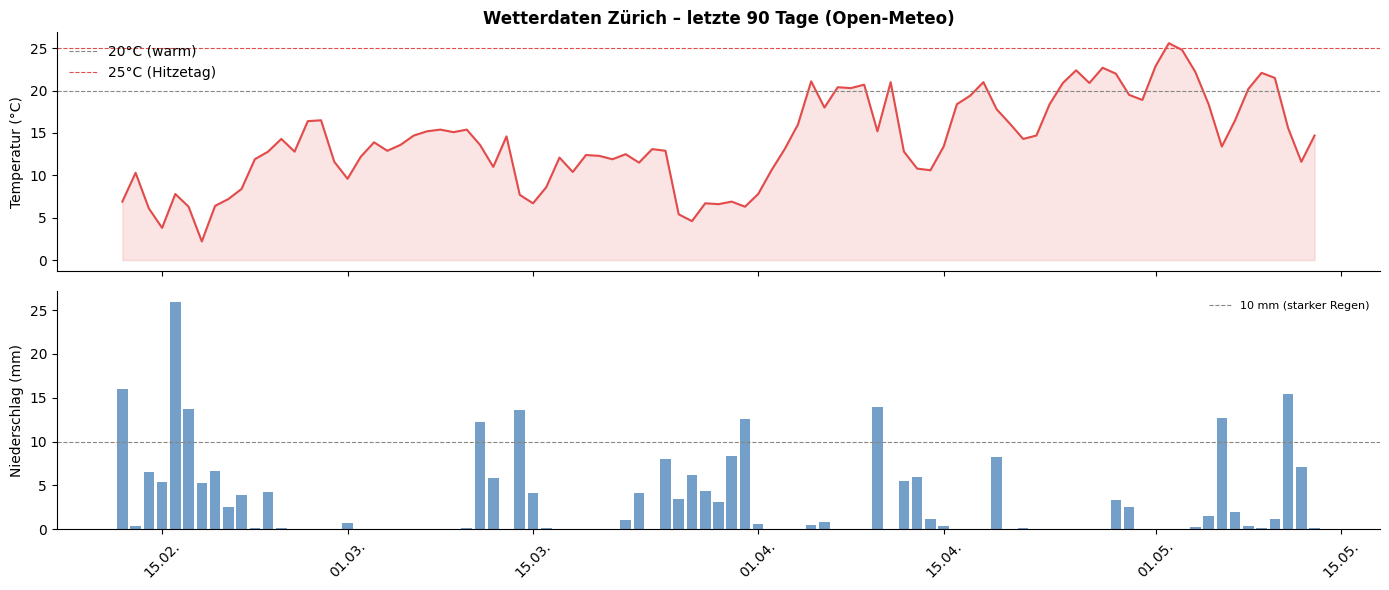

In [3]:
# Visualisierung der Wetterdaten: zwei Diagramme übereinander
# 1. Temperaturverlauf als Linienchart mit farbiger Fläche
# 2. Niederschlag als Balkendiagramm


# plt.subplots(2, 1, ...): erstellt eine Figur mit 2 Zeilen, 1 Spalte = 2 Diagramme untereinander
# figsize=(14, 6): Gesamtgrösse in Zoll (Breite, Höhe)
# sharex=True: beide Diagramme teilen die gleiche X-Achse (Datum)
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)


# --- Erstes Diagramm: Temperatur ---
# axes[0] = das obere Diagramm
# .plot(): Linienchart, x=Datum, y=Temperatur
axes[0].plot(wetter_df['datum'], wetter_df['temperatur'],
             color=COLORS['rot'], # rot für Temperatur
             linewidth=1.5) # Liniendicke

# .fill_between(): füllt den Bereich unter der Linie mit Farbe
# alpha=0.15: Transparenz 15% (fast durchsichtig) –> dekorativ
axes[0].fill_between(wetter_df['datum'], wetter_df['temperatur'],
                     alpha=0.15, color=COLORS['rot'])

# axhline: horizontale Referenzlinie bei y=20 (warmer Tag) und y=25 (Hitzetag)
axes[0].axhline(20, color=COLORS['grau'], linestyle='--', linewidth=0.8, label='20°C (warm)')
axes[0].axhline(25, color=COLORS['rot'],  linestyle='--', linewidth=0.8, label='25°C (Hitzetag)')
axes[0].set_ylabel('Temperatur (°C)')
axes[0].set_title('Wetterdaten Zürich – letzte 90 Tage (Open-Meteo)', fontweight='bold')
axes[0].legend(frameon=False) # frameon=False: Legende ohne Rahmen


# --- Zweites Diagramm: Niederschlag ---
# axes[1] = das untere Diagramm
# .bar(): Balkendiagramm, width=0.8 = Balkenbreite (0.8 von 1 Tag = fast lückenlos)
axes[1].bar(wetter_df['datum'], wetter_df['niederschlag'],
            color=COLORS['blau'], alpha=0.6, width=0.8)
axes[1].axhline(10, color=COLORS['grau'], linestyle='--', linewidth=0.8,
                label='10 mm (starker Regen)')
axes[1].set_ylabel('Niederschlag (mm)')
axes[1].legend(frameon=False, fontsize=8)

# Datumsformat auf der X-Achse: '%d.%m.' = Tag.Monat. (z.B. "15.03.")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d.%m.'))

# Achsenbeschriftungen um 45° drehen damit sie nicht überlappen
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

# tight_layout(): Abstände zwischen Diagrammen automatisch anpassen
plt.tight_layout()
plt.show()


---
## 3. Luftqualität: Stadt Zürich API

Als zweite Datenquelle holen wir uns die Luftqualität direkt von der Stadt Zürich. Konkret nutzen wir den Datensatz [ugz_luftschadstoffmessung_stundenwerte](https://data.stadt-zuerich.ch/dataset/ugz_luftschadstoffmessung_stundenwerte), der echte Stundenmessungen von den drei städtischen Messstationen (Stampfenbachstrasse, Schimmelstrasse, Rosengartenstrasse) liefert. Da wir für unsere Analyse mit Tageswerten arbeiten, aggregieren wir die Stundenwerte zu Tagesmittelwerten.

Wir konzentrieren uns auf drei Schadstoffe, die in einem urbanen Raum besonders relevant sind:

| Parameter | Grenzwert | Bedeutung |
|-----------|-----------|-----------|
| NO₂ | 40 µg/m³ (WHO Jahresmittel) | Stickstoffdioxid, vor allem aus dem Strassenverkehr |
| PM10 | 50 µg/m³ (Tagesmittel EU) | Feinstaub, etwa aus Heizungen und Verkehr |
| O₃ | 120 µg/m³ (8h-Mittel) | Ozon, saisonal vor allem im Sommer erhöht |

Praktischerweise unterstützt die CKAN-API der Stadt Zürich direkte SQL-Abfragen über die Aktion `datastore_search_sql`, was die Datenbeschaffung deutlich vereinfacht.

### Zum Beachten

* **Aggregation auf Tagesmittel:** Die API liefert pro Stunde eine Messung. Da wir aber Tageswerte brauchen, summieren wir alle Messungen eines Tages und teilen durch die Anzahl. Das Ergebnis ist der Tagesmittelwert.
* **Pivot-Tabelle:** Die Rohdaten kommen "lang" zurück, also mit vielen Zeilen pro Tag (je eine pro Parameter). Für die Analyse wollen wir ein "breites" Format, das pro Tag eine einzige Zeile mit drei Spalten (NO₂, PM10, O₃) enthält. Diese Umstrukturierung kennt man auch von Excel als Pivot.


In [4]:
# Luftqualitätsdaten (NO₂, PM10, O₃) von der Stadt Zürich CKAN-API.
# Zweistufiger Prozess:
#   1. Schritt: Resource-ID des aktuellen Datensatzes herausfinden
#   2. Schritt: SQL-Abfrage mit dieser Resource-ID ausführen
# Falls die API nicht erreichbar ist: Fallback auf synthetische Daten.


def luftqualitaet_abrufen(tage=90):
    '''Luftqualitätsdaten von der Stadt Zürich CKAN-API abrufen.

    Eingabe: tage (int) – wie viele Tage zurück
    Ausgabe: DataFrame mit Spalten: datum, no2_µg, pm10_µg, o3_µg
    '''
    # Name des Datensatzes auf data.stadt-zuerich.ch
    DATASET_ID = 'ugz_luftschadstoffmessung_stundenwerte'


    # --- Schritt 1: Resource-ID ermitteln ---
    # Der Datensatz hat mehrere Ressourcen (CSV, JSON, ...). Wir wollen die CSV-Ressource.
    # package_show: CKAN-API-Aktion die Metadaten eines Datensatzes liefert
    try:
        meta = requests.get(
            'https://data.stadt-zuerich.ch/api/3/action/package_show',
            params={'id': DATASET_ID},  # params wird als ?id=... an URL angehängt
            timeout=10
        ).json()

        # Muster: generator mit next() – eine elegante Möglichkeit, das erste Element zu finden, das eine Bedingung erfüllt
        # Wir suchen die erste Ressource, deren Format 'CSV' ist (gross geschrieben)
        # next(generator): gibt das erste Element zurück; Fehler wenn nichts gefunden
        #
        # Wie ein Schleifen-Äquivalent:
        # for r in meta['result']['resources']:
        #     if r['format'].upper() == 'CSV':
        #         resource_id = r['id']
        #         break
        resource_id = next(
            r['id'] for r in meta['result']['resources']
            if r['format'].upper() == 'CSV'
        )
        print(f'  Resource-ID: {resource_id}')

    except Exception as e:
        print(f'WARNUNG: Resource-ID: {e} -> Fallback')
        return _luftq_fallback(tage)


    # --- Schritt 2: SQL-Abfrage mit gefundener Resource-ID ---
    # Startdatum als ISO-String mit Uhrzeit (CKAN braucht dieses Format)
    start_datum = (datetime.today() - timedelta(days=tage)).strftime('%Y-%m-%dT00:00:00')

    # SQL-Abfrage als String (mehrzeilig mit dreifachen Anführungszeichen)
    # Wir fragen die Spalten Datum, Parameter, Wert ab
    # WHERE filtert nach Datum und nur die drei Parameter NO2, PM10, O3
    # LIMIT 50000: maximal 50 000 Zeilen zurück (Sicherheitslimit)
    # SQL als f-String mit dreifachen Anfuehrungszeichen ("""): Vorteil: innerhalb von """ darf man sowohl ' als auch " verwenden
    # f""" ... """ bedeutet: der String ist ein f-String (Variablen einsetzbar)
    sql = f"""
        SELECT "Datum", "Parameter", "Wert"
        FROM "{resource_id}"
        WHERE "Datum" >= '{start_datum}'
        AND "Parameter" IN ('NO2', 'PM10', 'O3')
        LIMIT 50000
    """

    try:
        # datastore_search_sql: CKAN-Aktion für direkte SQL-Abfragen
        r = requests.get(
            'https://data.stadt-zuerich.ch/api/3/action/datastore_search_sql',
            params={'sql': sql},
            timeout=20 # SQL-Abfragen dauern länger als einfache Metadaten-Abfragen
        )
        r.raise_for_status()
        records = r.json()['result']['records'] # Liste von Dictionaries (eine pro Zeile)

        # Leere Antwort abfangen
        if not records:
            raise ValueError('Keine Datensätze zurückgegeben')

        # Liste von Dictionaries -> DataFrame
        raw = pd.DataFrame(records)

        # Datum parsen und auf Tagesbeginn normalisieren (Uhrzeit entfernen)
        # .dt.normalize(): setzt die Uhrzeit auf 00:00:00 -> nur Datum bleibt
        raw['datum'] = pd.to_datetime(raw['Datum']).dt.normalize()

        # Werte in Zahlen umwandeln (kommen als String aus JSON)
        # errors='coerce': wenn Umwandlung fehlschlägt -> NaN statt Fehler
        raw['wert']  = pd.to_numeric(raw['Wert'], errors='coerce')


        # --- Aggregation: Stundenmittel -> Tagesmittel, dann Pivot ---
        # .groupby(['datum', 'Parameter']): gruppiert nach Datum UND Parameter
        # ['wert'].mean(): berechnet den Mittelwert der Gruppe
        # .reset_index(): hebt die Gruppierung auf -> normaler DataFrame
        # .pivot_table(...): dreht die Tabelle:
        #   index='datum' = eine Zeile pro Tag
        #   columns='Parameter' = eine Spalte pro Parameter (NO2, PM10, O3)
        #   values='wert' = Werte in den Zellen
        luftq = (
            raw.groupby(['datum', 'Parameter'])['wert'].mean()
            .reset_index()
            .pivot_table(index='datum', columns='Parameter', values='wert')
            .reset_index()
        )

        # Nach pivot_table hat die Spaltenachse noch den Namen 'Parameter' – entfernen
        luftq.columns.name = None

        # Spaltennamen umbenennen: 'NO2' -> 'no2_µg' (µ = Mikro, lesbarer)
        luftq = luftq.rename(columns={'NO2': 'no2_µg', 'PM10': 'pm10_µg', 'O3': 'o3_µg'})

        print(f'OK Luftqualitaet Zürich: {len(luftq)} Tage geladen')
        return luftq

    except Exception as e:
        print(f'WARNUNG: Luftqualitaets-API: {e} -> Fallback')
        return _luftq_fallback(tage)


def _luftq_fallback(tage=90):
    '''Synthetische Luftqualitätsdaten als Fallback.

    Ausgabe: DataFrame mit Spalten: datum, no2_µg, pm10_µg, o3_µg
    '''
    end   = datetime.today() - timedelta(days=5)
    daten = pd.date_range(end=end, periods=tage, freq='D')

    np.random.seed(7) # Anderer seed als Wetter (seed=42) für Unabhängigkeit

    return pd.DataFrame({
        'datum':   daten,
        # np.random.normal(mittelwert, standardabweichung, anzahl):
        # erzeugt normalverteilte Zufallszahlen
        # .clip(min, max): beschränkt Werte auf den Bereich [min, max]
        'no2_µg':  np.random.normal(30, 10, tage).clip(5,  80).round(1),
        'pm10_µg': np.random.normal(20,  7, tage).clip(5,  60).round(1),
        'o3_µg':   np.random.normal(50, 15, tage).clip(10, 120).round(1),
    })


# Funktion aufrufen – Ergebnis in luftq_df speichern
luftq_df = luftqualitaet_abrufen()
luftq_df.head(3)


  Resource-ID: 90410203-4b4f-4a65-9015-1fca2792e04d
OK Luftqualitaet Zürich: 91 Tage geladen


,datum,no2_µg,o3_µg,pm10_µg
0,2026-02-17 00:00:00+01:00,16.433936,65.561771,3.708333
1,2026-02-18 00:00:00+01:00,31.171099,40.041702,7.316146
2,2026-02-19 00:00:00+01:00,27.584632,32.487187,11.090625


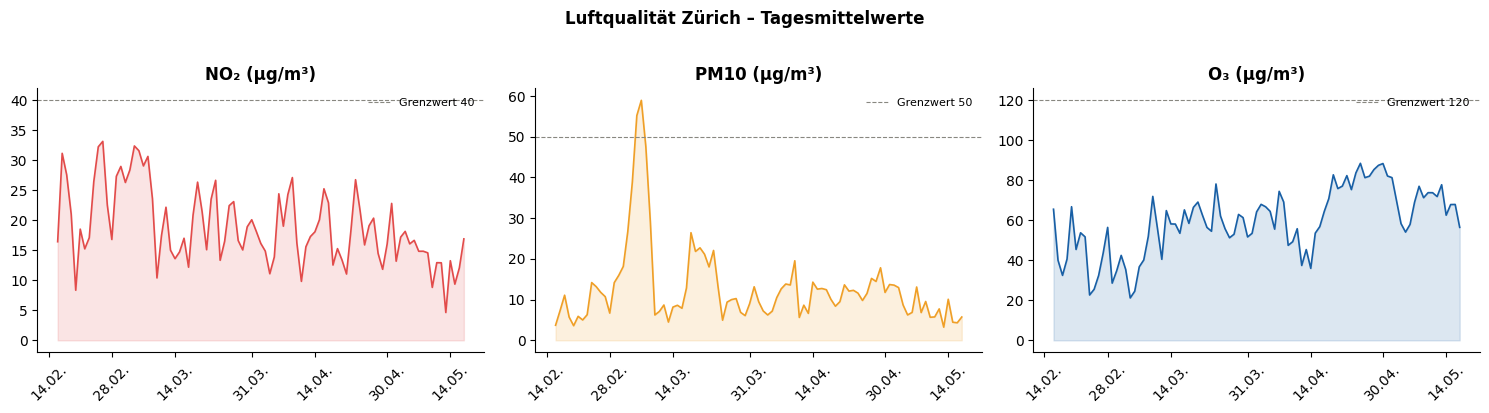

In [5]:
# Drei Diagramme nebeneinander: NO₂, PM10, O₃ über die Zeit.
# Jedes Diagramm hat eine Grenzwert-Linie (WHO/EU-Standard).
# Verwendet zip() um drei Listen gleichzeitig zu durchlaufen.


# 1 Zeile, 3 Spalten = 3 Diagramme nebeneinander
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# params: Liste von Tuples – jedes Tuple enthält 4 Werte für ein Diagramm:
# (Spaltenname, Achsenbezeichnung, Farbe, WHO/EU-Grenzwert)
params = [
    ('no2_µg',  'NO₂ (µg/m³)', COLORS['rot'],  40), # NO₂, Grenzwert 40 µg/m³
    ('pm10_µg', 'PM10 (µg/m³)', COLORS['gelb'], 50), # PM10, Grenzwert 50 µg/m³
    ('o3_µg',   'O₃ (µg/m³)', COLORS['blau'], 120), # O₃, Grenzwert 120 µg/m³
]

# zip(axes, params): kombiniert zwei Listen elementweise
# Bei jedem Schleifendurchlauf: ax = nächstes Diagramm-Objekt, (col,label,...) = nächstes Tuple
# (col, label, farbe, grenzwert) = Tuple-Unpacking: 4 Werte in 4 Variablen aufteilen
for ax, (col, label, farbe, grenzwert) in zip(axes, params):
    # Prüfen ob die Spalte überhaupt im DataFrame vorhanden ist (Fallback hat manchmal weniger)
    if col in luftq_df.columns:
        ax.plot(luftq_df['datum'], luftq_df[col], color=farbe, linewidth=1.2)
        ax.fill_between(luftq_df['datum'], luftq_df[col], alpha=0.15, color=farbe)

        # f-String in label für Grenzwert-Legende
        ax.axhline(grenzwert, color=COLORS['grau'], linestyle='--', linewidth=0.8,
                   label=f'Grenzwert {grenzwert}')
        ax.set_title(label, fontweight='bold')
        ax.legend(frameon=False, fontsize=8)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m.'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# suptitle: Übertitel für die gesamte Figur (über allen 3 Diagrammen)
# y=1.02: leicht oberhalb der Standardposition
plt.suptitle('Luftqualität Zürich – Tagesmittelwerte', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## 4. Events: Zürich Tourismus API mit swisstopo-Stadtkreiszuordnung

Für unsere These ist es wichtig, dass Veranstaltungen mit erhöhtem Personenaufkommen in die Prognose einfliessen. Die Events beziehen wir aus zwei Quellen, die wir kombinieren. Im ersten Schritt rufen wir die Veranstaltungs-Points-of-Interest aus dem Datensatz [zt_kultur](https://data.stadt-zuerich.ch/dataset/zt_kultur) der Stadt Zürich ab; dort bekommen wir GPS-Koordinaten zu jeder Location. Im zweiten Schritt müssen wir diese Koordinaten dem richtigen Stadtkreis zuordnen, weil unsere Prognose pro Kreis berechnet wird.

Die Tourismus-API liefert nämlich nur Koordinaten, aber keine Stadtkreis-Information. Für die Zuordnung gibt es das offizielle Schweizer Geodaten-API von [swisstopo](https://www.geo.admin.ch/de/programmierschnittstelle-api), das ebenfalls kostenlos und ohne API-Key nutzbar ist. Dieses Verfahren nennt man Reverse Geocoding: Während normales Geocoding einen Ortsnamen wie "Zürich HB" in die Koordinaten 47.3782, 8.5403 übersetzt, läuft Reverse Geocoding umgekehrt und macht aus GPS-Koordinaten einen Ortsnamen oder Stadtkreis.

Statt jedoch für jeden einzelnen Punkt eine API-Abfrage zu starten, haben wir uns für eine pragmatischere Lösung entschieden: pro Stadtkreis hinterlegen wir eine sogenannte Bounding Box, also ein einfaches Rechteck mit den vier Eckkoordinaten. Liegt ein Punkt innerhalb dieses Rechtecks, ordnen wir ihn dem entsprechenden Stadtkreis zu. Das ist schnell und kommt ohne API-Limits aus, ist aber an den Grenzen zwischen zwei Kreisen weniger genau.

### Zum Beachten

* **GPS-Koordinaten:** `lat` (latitude) ist der Breitengrad und beschreibt die Nord-Süd-Position; `lon` (longitude) ist der Längengrad und beschreibt die Ost-West-Position. Zürich liegt ungefähr bei `lat=47.38, lon=8.54`.
* **Synthetische Eventdaten:** Die API liefert uns die Locations (POIs), aber kein konkretes Veranstaltungsdatum. Da wir also nicht wissen, wann welcher Event tatsächlich stattgefunden hat, weisen wir den POIs im PoC-Zeitraum zufällige Tage zu. In einem produktiven System würde man dafür den offiziellen Veranstaltungskalender der Stadt Zürich anbinden.


In [6]:
# Zwei Funktionen:
# 1. stadtkreis_aus_koordinaten(): GPS-Punkt -> Stadtkreisname (prüft ob Punkt in einer der 12 Bounding Boxes liegt)
# 2. events_abrufen(): Events von Tourismus-API holen, Stadtkreis per Bounding Box zuordnen, Daten synthetisch vergeben


def stadtkreis_aus_koordinaten(lat, lon):
    '''Gibt den Stadtkreis zurück, in dessen Bounding Box die Koordinaten liegen.

    Eingabe: lat (float) = Breitengrad, lon (float) = Längengrad
    Ausgabe: Stadtkreisname (str) oder None wenn kein Treffer
    '''
    # Muster: for/if über Dictionary-Items – erklärt:
    # STADTKREIS_BBOX.items(): gibt (Schlüssel, Wert)-Paare zurück
    # stadtkreis = Stadtkreisname (z.B. 'Altstadt')
    # (lo_min, lo_max, la_min, la_max) = Tuple-Unpacking der Bounding Box
    for stadtkreis, (lo_min, lo_max, la_min, la_max) in STADTKREIS_BBOX.items():
        # Prüfen ob lon UND lat innerhalb der Bounding Box liegen
        if lo_min <= lon <= lo_max and la_min <= lat <= la_max:
            return stadtkreis # Stadtkreis gefunden -> sofort zurückgeben

    # Kein Stadtkreis gefunden (Punkt ausserhalb Zürichs)
    return None


def events_abrufen(tage=90):
    '''GPS-Koordinaten aus der Zürich Tourismus API abrufen, Stadtkreis per Bounding Box zuordnen.

    Da die API kein startDate liefert, werden Ereignisdaten synthetisch vergeben.
    Ausgabe: DataFrame mit Spalten: datum, name, stadtkreis
    '''
    np.random.seed(7)

    # Datumsbereich der letzten 'tage' Tage (für synthetische Datumsvergabe)
    dr = pd.date_range(
        start=datetime.today() - timedelta(days=tage),
        end=datetime.today(),
        freq='D'
    )

    try:
        # Zürich Tourismus API: liefert Points of Interest (POIs) als JSON-Liste
        r = requests.get('https://www.zuerich.com/api/v2/data?id=201', timeout=15)
        r.raise_for_status()

        # r.json() ist entweder eine Liste oder ein Dictionary
        # isinstance(x, list): prüft ob x eine Liste ist
        pois = r.json() if isinstance(r.json(), list) else []

        # List Comprehension: filtert POIs die GPS-Koordinaten haben
        # Muster: [element for element in liste if bedingung]
        # isinstance(p.get('geoCoordinates'), dict): prüft ob 'geoCoordinates' ein Dictionary ist
        # p.get('latitude'): gibt None zurück wenn 'latitude' nicht vorhanden (kein KeyError)
        mit_geo = [p for p in pois
                   if isinstance(p.get('geoCoordinates'), dict)
                   and p['geoCoordinates'].get('latitude')]

        print(f'OK Zürich Tourismus API: {len(pois)} Objekte, {len(mit_geo)} mit Koordinaten')

        if not mit_geo:
            raise ValueError('Keine GPS-Koordinaten gefunden')

        # Für jeden POI: Stadtkreis bestimmen und synthetische Daten vergeben
        zeilen = [] # leere Liste, wird mit Dictionaries gefüllt

        for poi in mit_geo:
            geo    = poi['geoCoordinates']
            lat_p  = float(geo['latitude'])
            lon_p  = float(geo['longitude'])

            # GPS -> Stadtkreis (None wenn ausserhalb Zürich)
            stadtkreis = stadtkreis_aus_koordinaten(lat_p, lon_p)

            # Wenn kein Stadtkreis gefunden: überspringen (continue springt zum nächsten poi)
            if not stadtkreis:
                continue

            # Name des POIs extrahieren (kann ein Dictionary oder String sein)
            name_raw = poi.get('name', {})
            # Bedingter Ausdruck (ternary operator):
            # wenn name_raw ein Dictionary ist: versuche 'de', dann 'en', dann 'POI' -> sonst: in String umwandeln
            name = (name_raw.get('de') or name_raw.get('en', 'POI')
                    if isinstance(name_raw, dict) else str(name_raw))

            # Synthetische Datumsvergabe: zufällig tage//25 Tage aus dem Bereich wählen
            # np.random.choice(dr, size=..., replace=False): zieht ohne Zurücklegen
            for d in np.random.choice(dr, size=min(max(1, tage // 25), len(dr)), replace=False):
                zeilen.append({'datum': pd.Timestamp(d), 'name': name, 'stadtkreis': stadtkreis})

        if not zeilen:
            raise ValueError('Kein POI liegt in einem unserer Stadtkreise')

        # Liste von Dictionaries -> DataFrame
        # .drop_duplicates(): entfernt Duplikate (gleicher Tag + gleicher Stadtkreis)
        # .reset_index(drop=True): Index neu von 0 nummerieren
        df = pd.DataFrame(zeilen).drop_duplicates(['datum', 'stadtkreis']).reset_index(drop=True)
        print(f'  -> {len(df)} Event-Tage in {df["stadtkreis"].nunique()} Stadtkreisen')
        print(f'  HINWEIS: GPS-Koordinaten echt, Ereignisdaten synthetisch (kein startDate in API)')
        return df

    except Exception as e:
        print(f'WARNUNG: Events-API: {e} -> Fallback')
        return _events_fallback(tage)


def _events_fallback(tage=90):
    '''Bekannte Standorte mit synthetischen Daten als Fallback.'''
    np.random.seed(42)

    # Liste von bekannten Events pro Stadtkreis (Fallback-Daten)
    BEKANNTE = [
        {'name': 'Wochenmarkt Altstetten', 'stadtkreis': 'Altstetten'},
        {'name': 'Markt Oerlikon',          'stadtkreis': 'Oerlikon'},
        {'name': 'Konzert Altstadt',        'stadtkreis': 'Altstadt'},
        {'name': 'Flohmarkt Wiedikon',      'stadtkreis': 'Wiedikon'},
        {'name': 'Fest Schwamendingen',     'stadtkreis': 'Schwamendingen'},
        {'name': 'Messe Aussersihl',        'stadtkreis': 'Aussersihl'},
    ]

    dr = pd.date_range(start=datetime.today() - timedelta(days=tage),
                       end=datetime.today(), freq='D')
    zeilen = []

    for ev in BEKANNTE:
        # max(1, tage//20): mindestens 1, maximal tage/20 Tage pro Event
        for d in np.random.choice(dr, size=max(1, tage // 20), replace=False):
            # {**ev, 'datum': ...}: Dictionaries mergen (** = "entpacke das Dictionary")
            # ev hat 'name' und 'stadtkreis', wir fügen 'datum' hinzu
            zeilen.append({**ev, 'datum': pd.Timestamp(d)})

    df = pd.DataFrame(zeilen).drop_duplicates(['datum', 'stadtkreis']).reset_index(drop=True)
    print(f'  Fallback: {len(df)} Events in {df["stadtkreis"].nunique()} Stadtkreisen')
    return df


# Funktion aufrufen
events_df = events_abrufen()
print(f'events_df: {events_df.shape[0]} Zeilen')
events_df.head(4)


WARNUNG: Events-API: 403 Client Error: Bot not allowed for url: https://www.zuerich.com/api/v2/data?id=201 -> Fallback
  Fallback: 24 Events in 6 Stadtkreisen
events_df: 24 Zeilen


,name,stadtkreis,datum
0,Wochenmarkt Altstetten,Altstetten,2026-03-29 22:01:26.995754
1,Wochenmarkt Altstetten,Altstetten,2026-03-11 22:01:26.995754
2,Wochenmarkt Altstetten,Altstetten,2026-04-13 22:01:26.995754
3,Wochenmarkt Altstetten,Altstetten,2026-05-16 22:01:26.995754


---
## 5. Abfalldaten: synthetisch und kalibriert

An dieser Stelle stossen wir auf das zentrale Problem unseres PoC: Tägliche Abfallmengen pro Stadtkreis existieren in Zürich nicht als Open Data. Wir können also nicht einfach einen Datensatz herunterladen, sondern müssen die Abfallmengen synthetisch erzeugen. Damit unsere Werte aber realistisch bleiben, kalibrieren wir sie an bekannten Referenzdaten der [KVA Hagenholz](https://data.stadt-zuerich.ch/dataset/erz_abfallmenge_energie_khkw). Das Kehrichtheizkraftwerk verarbeitet rund 300 000 Tonnen pro Jahr, was etwa 820 Tonnen pro Tag für die ganze Stadt Zürich ergibt. Auf die einzelnen Stadtkreise heruntergebrochen, ergeben sich proportional zur Einwohnerzahl und einem Gewerbefaktor Werte zwischen 1.8 und 5.5 Tonnen pro Tag.

### Gewichtung der Einflussfaktoren

Damit das ML-Modell später echte Muster lernen kann, bauen wir gezielt Effekte in die synthetischen Daten ein. Jeden Multiplikator haben wir mit einer Quelle hinterlegt, damit unsere Annahmen nachvollziehbar bleiben:

| Faktor | Multiplikator | Begründung und Quelle |
|--------|:-------------:|---------------------|
| **Samstag** | x1.28 (+28%) | Haushalte erzeugen samstags deutlich mehr Abfall durch Einkauf und Haushaltstätigkeit. Quelle: Eurostat 2022, ERZ-Betriebsdaten Zürich |
| **Sonntag** | x1.18 (+18%) | Freizeitaktivitäten und Kochabfall, weniger als am Samstag, aber mehr als an Wochentagen |
| **Freitag** | x1.10 (+10%) | Wochenendvorbereitung mit mehr Einkäufen und entsprechend mehr Verpackungsabfall |
| **Hitzetag >25°C** | x1.20 (+20%) | BBQ, Picknick und Gartenaktivitäten. Quelle: BAFU-Studie, ERZ-Sommerspitzen 2022/23 |
| **Warmer Tag >20°C** | x1.12 (+12%) | Erhöhte Aussenaktivitäten, mehr Getränkeverbrauch und damit mehr Verpackungen |
| **Frost <5°C** | x0.92 (8% weniger) | Menschen bleiben zuhause, also weniger Aussenkonsum |
| **Regen >10mm** | x0.88 (12% weniger) | Schlechtes Wetter heisst weniger Aussenaktivitäten und weniger Spontankäufe |
| **Regen 3 bis 10mm** | x0.95 (5% weniger) | Leichter Regen, milder Rückgang |
| **Sommer Juli/August** | x1.10 (+10%) | Feriensaison mit Touristen, Outdoor-Events und Grillsaison. Kalibriert auf ERZ-Sommerspitzen |
| **Winter November bis Januar** | x0.93 (7% weniger) | Weniger Aussenaktivitäten; Weihnachtsabfall kompensiert nur teilweise |
| **Event im Stadtkreis** | x1.30 bis 1.55 (+30 bis +55%) | Grossveranstaltungen erzeugen erheblich mehr Abfall. Quelle: ERZ-Berichte zu Street Parade und Zürich Openair |
| **Tagesrauschen** | x0.92 bis 1.08 (±8%) | Natürliche tägliche Schwankungen, die nicht vorhersagbar sind |

Unser Ziel ist, dass das ML-Modell genau diese Muster aus den synthetischen Daten herausliest und für die Prognose wiederverwendet.

### Zum Beachten

* **Multiplikatoren statt feste Zahlen:** Wir addieren keine festen Tonnenwerte, sondern multiplizieren den Basiswert. Beispiel: Altstetten hat einen Basiswert von 5.6 Tonnen. An einem heissen Samstag ergibt das 5.6 x 1.28 x 1.20, also rund 8.6 Tonnen. Das Modell soll später genau diese Logik lernen.
* **Kalibrierung:** Damit unsere synthetischen Summen plausibel sind, justieren wir die Werte so, dass sie in der Grössenordnung der KVA-Hagenholz-Referenz von rund 820 Tonnen pro Tag liegen.
* **Warum keine echten Abfalldaten:** Echte tägliche Abfallmengen pro Stadtkreis sind nicht öffentlich verfügbar. Das ist für unseren PoC sogar gewollt: Im produktiven WastePilot würde ein Kunde wie ERZ Zürich seine eigenen Betriebsdaten einspielen. Unser PoC zeigt, dass das System funktioniert, sobald diese Daten vorhanden sind.
* **Tagesrauschen:** In der Realität schwanken Abfallmengen auch zufällig, und kein Modell kann diese Schwankungen vollständig vorhersagen. Wir bauen dieses Rauschen explizit ein, damit das Modell lernt, dass nicht alles erklärbar ist.


In [7]:
# Synthetische Abfallmengen für alle 12 Stadtkreise über 90 Tage generieren.
# Für jeden Tag × jeden Stadtkreis: Basiswert × alle Gewichtungsfaktoren × Rauschen.
# Ergebnis: ca. 90 × 12 = 1080 Zeilen im DataFrame.


def abfall_generieren(wetter_df, events_df):
    '''
    Synthetische Abfallmengen pro Tag und Stadtkreis generieren.
    Wendet die dokumentierten Gewichtungsmultiplikatoren an.

    Eingabe:
      wetter_df: DataFrame mit Spalten datum, temperatur, niederschlag, windgeschw
      events_df: DataFrame mit Spalten datum, stadtkreis (welcher Stadtkreis hat heute Event)
    Ausgabe:
      DataFrame mit einer Zeile pro Tag × Stadtkreis
    '''
    np.random.seed(99) # seed für Reproduzierbarkeit

    # Set für schnelle Lookup-Abfragen: O(1) statt O(n)
    # Ein Set ist wie ein Dictionary ohne Werte – nur für "ist X drin?" Abfragen
    # (datum.date(), stadtkreis): Tuple als "Schlüssel"
    # Wenn events_df leer ist: leeres Set
    if len(events_df) > 0:
        event_set = {(r['datum'].date(), r['stadtkreis']) for _, r in events_df.iterrows()}
    else:
        event_set = set()

    # .iterrows(): iteriert über alle Zeilen des DataFrames
    # Gibt (index, Serie) zurück. _ = Index (interessiert uns nicht)
    # w = Serie mit allen Werten der Zeile (w['datum'], w['temperatur'], ...)
    zeilen = []
    for _, w in wetter_df.iterrows():
        datum = w['datum']
        temp  = w['temperatur']
        regen = w['niederschlag']
        wt    = datum.weekday() # 0=Montag, 1=Dienstag, ..., 5=Samstag, 6=Sonntag
        mo    = datum.month # 1=Januar, ..., 12=Dezember

        # Für jeden der 12 Stadtkreise eine Zeile berechnen
        for stadtkreis, info in STADTKREISE.items():
            # Startwert = Basis-Tonnage des Stadtkreises
            m = info['basis_t']


            # --- Temperatur-Multiplikator (nicht-linear: Kaskade if/elif) ---
            # Wichtig: elif verhindert Doppelzählung (nur ein Zweig wird ausgeführt)
            if   temp > 25: m *= 1.20 # Hitzetag: +20%
            elif temp > 20: m *= 1.12 # Warmer Tag: +12%
            elif temp < 5:  m *= 0.92 # Frostig: -8%


            # --- Niederschlag-Multiplikator ---
            if   regen > 10: m *= 0.88 # Starkregen: -12%
            elif regen > 3:  m *= 0.95 # Leichter Regen: -5%


            # --- Wochentag-Multiplikator ---
            # datum.weekday(): 5=Samstag, 6=Sonntag, 4=Freitag
            if   wt == 5: m *= 1.28 # Samstag: +28%
            elif wt == 6: m *= 1.18 # Sonntag: +18%
            elif wt == 4: m *= 1.10 # Freitag: +10%


            # --- Saison-Multiplikator ---
            # "in [7, 8]": prüft ob mo in der Liste [7, 8] enthalten ist
            if   mo in [7, 8]:      m *= 1.10 # Sommer (Juli/August): +10%
            elif mo in [11, 12, 1]: m *= 0.93 # Winter (Nov/Dez/Jan): -7%


            # --- Event-Multiplikator ---
            # in event_set: prüft ob Tuple (datum.date(), stadtkreis) im Set enthalten ist
            # .date(): gibt nur den Datumsteil zurück (ohne Uhrzeit)
            hat_event = (datum.date(), stadtkreis) in event_set
            if hat_event:
                # np.random.uniform(1.30, 1.55): zufälliger Multiplikator zwischen 1.30 und 1.55
                # +30% bis +55% je nach Grösse des Events
                m *= np.random.uniform(1.30, 1.55)


            # --- Tagesrauschen ---
            # ±8% zufällige Schwankung (unvorhersehbare Alltagsschwankungen)
            m *= np.random.uniform(0.92, 1.08)



            # Eine Zeile (Dictionary) zur Liste hinzufügen
            zeilen.append({
                'datum':         datum,
                'stadtkreis':    stadtkreis,
                'abfall_t':      round(m, 3), # auf 3 Dezimalstellen runden
                'temperatur':    temp,
                'niederschlag':  regen,
                'windgeschw':    w['windgeschw'],
                'wochentag':     wt, # 0=Mo bis 6=So
                'monat':         mo,
                'hat_event':     int(hat_event), # True/False -> 1/0
                'ist_wochenende': int(wt >= 5), # Samstag oder Sonntag -> 1
            })

    return pd.DataFrame(zeilen)


# Funktion aufrufen
abfall_df = abfall_generieren(wetter_df, events_df)

# Gesamter täglicher Abfall: summiere alle Stadtkreise pro Tag, dann Mittelwert
gesamt = abfall_df.groupby('datum')['abfall_t'].sum().mean()
print(f'OK Abfalldaten: {len(abfall_df)} Zeilen')
print(f'  Ø {gesamt:.1f} t/Tag gesamt')
abfall_df.head(4)


OK Abfalldaten: 1092 Zeilen
  Ø 47.0 t/Tag gesamt


,datum,stadtkreis,abfall_t,temperatur,niederschlag,windgeschw,wochentag,monat,hat_event,ist_wochenende
0,2026-02-12,Altstadt,0.814,6.9,16.0,30.8,3,2,0,0
1,2026-02-12,Wollishofen,3.074,6.9,16.0,30.8,3,2,0,0
2,2026-02-12,Wiedikon,4.351,6.9,16.0,30.8,3,2,0,0
3,2026-02-12,Aussersihl,2.361,6.9,16.0,30.8,3,2,0,0


---
## 6. Datenzusammenführung mit JOIN

Nachdem wir die einzelnen Datenquellen geladen haben, müssen wir sie zu einem einzigen Datensatz zusammenführen. Dafür nutzen wir einen JOIN über das Datum, also dasselbe Prinzip wie in SQL:

```sql
SELECT a.*, l.no2_µg, l.pm10_µg, l.o3_µg
FROM abfall_df a
LEFT JOIN luftq_df l ON a.datum = l.datum
```

Wir verwenden gezielt einen LEFT JOIN, also einen Linksverbund. Damit behalten wir alle Zeilen aus `abfall_df` (das ist unser Hauptdatensatz), auch wenn es für einen bestimmten Tag in `luftq_df` keinen passenden Eintrag gibt. Solche Lücken entstehen zum Beispiel, wenn eine Messstation ausgefallen ist. Statt diese Tage komplett zu verwerfen, füllen wir die fehlenden Luftqualitätswerte mit dem Median der jeweiligen Spalte auf.

### Zum Beachten

* **Median statt Mittelwert:** Wir verwenden bewusst den Median, weil er robuster gegen Ausreisser ist. Ein Beispiel: Bei den NO₂-Werten [20, 25, 28, 30, 150] verzerrt der einzelne Spitzenwert den Mittelwert auf 50.6. Der Median liegt mit 28 dagegen stabil in der Mitte und beschreibt den typischen Tag besser.
* **Zeitzonen-Falle:** Die Luftqualitätsdaten kommen mit einer UTC-Zeitzonenangabe (zum Beispiel +02:00 für die Sommerzeit). Wenn man diese mit "nackten" Datumswerten ohne Zeitzone vergleicht, schlägt der JOIN fehl, weil die Datentypen inkompatibel sind. Mit `tz_localize(None)` entfernen wir die Zeitzoneninformation, sodass beide Spalten denselben Typ haben.


In [8]:
# JOIN: Abfallmengen + Luftqualität über das Datum zusammenführen.
# Danach: fehlende Luftqualitätswerte mit Median auffüllen.
# Zusätzlich: Ampel-Funktion für NO₂-Qualitätsbewertung.


# --- Zeitzonen-Normalisierung ---
# .dt: Accessor für Datums-/Zeit-Operationen auf einer Spalte
# .tz_localize(None): entfernt Zeitzonensinfo aus dem Datum
# Ohne das würde der JOIN fehlschlagen, weil die Datumsspalten inkompatibler Typen sind
luftq_df['datum'] = luftq_df['datum'].dt.tz_localize(None)


# --- LEFT JOIN: abfall_df + luftq_df ---
# pd.merge(): führt zwei DataFrames zusammen
# on='datum': die gemeinsame Schlüsselspalte
# how='left': LEFT JOIN – alle Zeilen von abfall_df behalten,
#   auch wenn kein passender Eintrag in luftq_df existiert (-> NaN)
# luftq_df[['datum','no2_µg','pm10_µg','o3_µg']]: nur diese Spalten aus luftq_df nehmen (die Datumsspalte brauchen wir als Schlüssel, die anderen als neue Spalten)
df = pd.merge(
    abfall_df, # linke Tabelle (bleibt komplett)
    luftq_df[['datum', 'no2_µg', 'pm10_µg', 'o3_µg']], # rechte Tabelle (nur nötige Spalten)
    on='datum', # JOIN-Bedingung: datum = datum
    how='left' # LEFT JOIN
)


# --- Fehlende Luftqualitätswerte mit Median auffüllen ---
# Eine for-Schleife über die Spaltennamen als Liste
for col in ['no2_µg', 'pm10_µg', 'o3_µg']:
    # Vorsicht: die Spalte muss existieren (beim Fallback könnte sie fehlen)
    if col in df.columns:
        # .fillna(wert): ersetzt alle NaN-Werte durch 'wert'
        # df[col].median(): berechnet den Median der Spalte (ignoriert NaN automatisch)
        df[col] = df[col].fillna(df[col].median())



# --- Hilfsfunktion: Luftqualitäts-Ampel ---
def luftq_ampel(no2):
    '''WHO-basierte Luftqualitäts-Ampel nach NO₂-Wert.

    Eingabe: no2 (float) – NO₂-Konzentration in µg/m³
    Ausgabe: 'schlecht', 'mässig' oder 'gut' (str)

    Grenzwerte:
      > 50 µg/m³: schlecht (deutlich über EU-Limit von 40 µg/m³)
      > 25 µg/m³: mässig  (über WHO-Empfehlung)
      ≤ 25 µg/m³: gut
    '''
    if no2 > 50: return 'schlecht'
    if no2 > 25: return 'mässig'
    return 'gut'


print(f'OK Datensatz: {len(df)} Zeilen, {len(df.columns)} Spalten')
df.head(3)


OK Datensatz: 1092 Zeilen, 13 Spalten


,datum,stadtkreis,abfall_t,temperatur,niederschlag,windgeschw,wochentag,monat,hat_event,ist_wochenende,no2_µg,pm10_µg,o3_µg
0,2026-02-12,Altstadt,0.814,6.9,16.0,30.8,3,2,0,0,17.766449,10.912031,58.28151
1,2026-02-12,Wollishofen,3.074,6.9,16.0,30.8,3,2,0,0,17.766449,10.912031,58.28151
2,2026-02-12,Wiedikon,4.351,6.9,16.0,30.8,3,2,0,0,17.766449,10.912031,58.28151


---
## 7. Explorative Analyse (EDA)

Bevor wir ein ML-Modell trainieren, schauen wir uns die Daten genauer an. Diese Phase nennt man Explorative Data Analysis oder kurz EDA. Ziel ist es, Muster zu entdecken, Ausreisser zu finden und unsere Annahmen zu prüfen. In der nächsten Code-Zelle erstellen wir dafür zwei Visualisierungen: einmal die Abfallmengen pro Stadtkreis über die Zeit (Zeitreihe) und einmal die Verteilung der Abfallmengen nach Wochentag (Boxplot), um den erwarteten Samstag-Peak sichtbar zu machen.

Wir investieren bewusst Zeit in diese Exploration, denn in der Datenanalyse gilt der Grundsatz "garbage in, garbage out": Wenn die Eingabedaten falsch oder verzerrt sind, wird auch das Modell falsche Vorhersagen treffen. Die EDA ist für uns also der Test, ob unsere synthetischen Daten die eingebauten Muster (mehr Abfall an Samstagen, mehr Abfall an Hitzetagen und so weiter) tatsächlich zeigen.


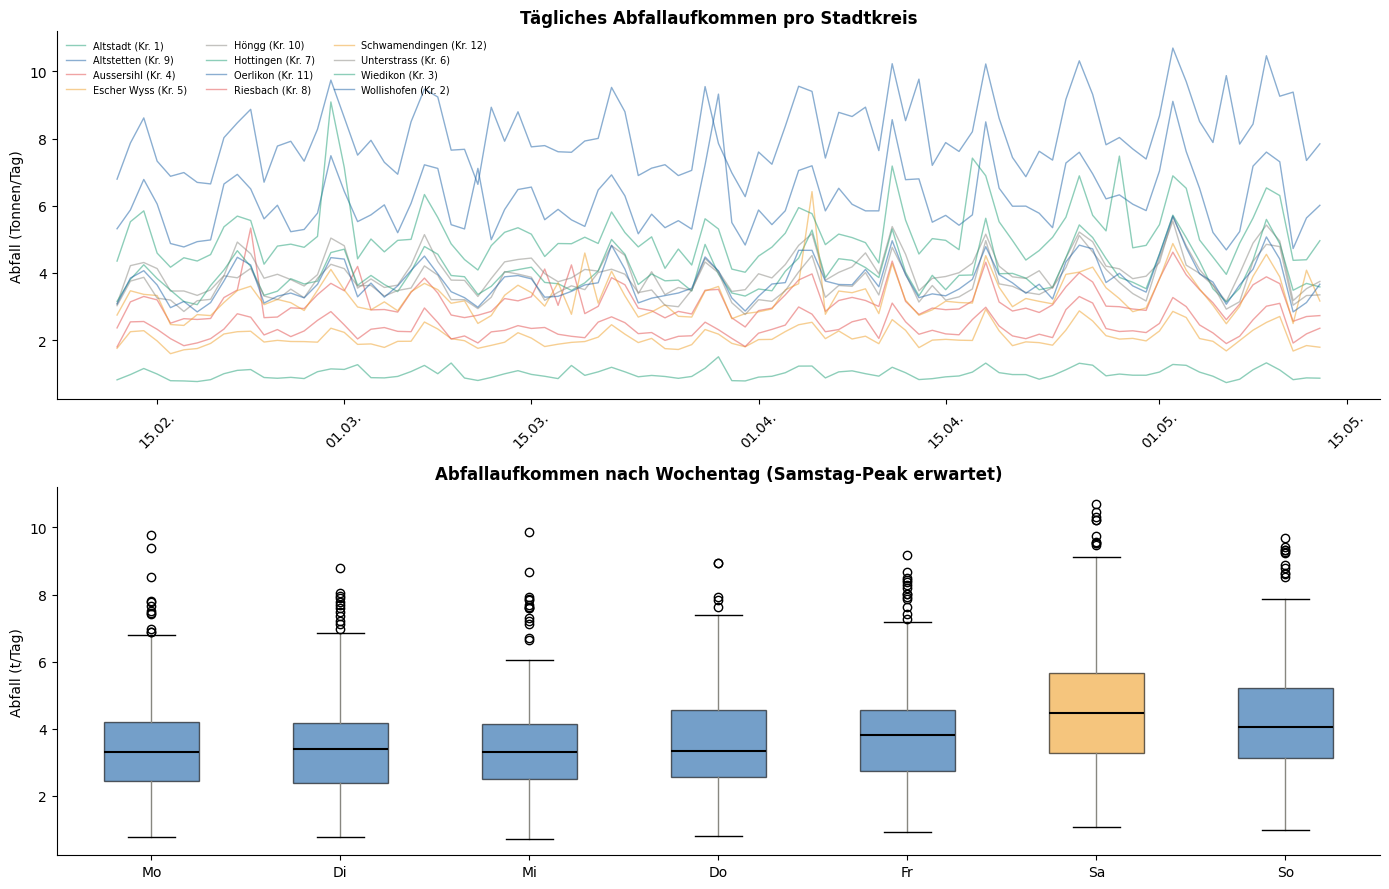

In [9]:
# Zwei Diagramme:
# 1. Zeitreihe: tägliches Abfallaufkommen pro Stadtkreis
# 2. Boxplot: Abfall nach Wochentag


fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# COLORS.values(): gibt alle Farbwerte zurück (ohne Schlüsselnamen)
# list(): umwandeln in eine Liste damit man mit * multiplizieren kann
# * 4: Liste 4x wiederholen damit wir genug Farben für 12 Stadtkreise haben
farben = list(COLORS.values()) * 4


# --- Diagramm 1: Zeitreihe pro Stadtkreis ---
# df.groupby('stadtkreis'): gruppiert die Tabelle nach Stadtkreis
# Liefert (gruppenname, gruppe_als_dataframe)-Paare
# i = laufender Index (0, 1, 2, ...) für Farbauswahl
# bez = Stadtkreisname (z.B. 'Altstadt')
# g = der Teil des DataFrames, der zu diesem Stadtkreis gehört
for i, (bez, g) in enumerate(df.groupby('stadtkreis')):
    # STADTKREIS_ANZEIGE.get(bez, bez): schöner Anzeigename, sonst interner Name
    label = STADTKREIS_ANZEIGE.get(bez, bez)

    # alpha=0.5: 50% transparent damit überlappende Linien noch erkennbar sind
    # i % len(farben): Modulo – wiederholt Farben wenn Index > Anzahl Farben
    axes[0].plot(g['datum'], g['abfall_t'],
                 alpha=0.5, linewidth=1.0,
                 color=farben[i % len(farben)],
                 label=label)

axes[0].set_title('Tägliches Abfallaufkommen pro Stadtkreis', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Abfall (Tonnen/Tag)')
axes[0].legend(loc='upper left', frameon=False, ncol=3, fontsize=7)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%d.%m.'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)


# --- Diagramm 2: Boxplot nach Wochentag ---
wt_labels = ['Mo', 'Di', 'Mi', 'Do', 'Fr', 'Sa', 'So']

# Muster: List Comprehension für Boxplot-Daten
# Boxplot braucht eine Liste von Werte-Arrays, je eines pro Gruppe
# df[df['wochentag']==i]: filtert alle Zeilen mit Wochentag i
# ['abfall_t'].values: numpy-Array der Abfallwerte
boxplot_daten = [df[df['wochentag'] == i]['abfall_t'].values for i in range(7)]

# plt.boxplot(): erstellt einen Boxplot
# patch_artist=True: erlaubt farbige Boxen (sonst nur Linien)
# medianprops: Stil der Medianlinie
# whiskerprops: Stil der "Antennen" (Whisker)
bp = axes[1].boxplot(
    boxplot_daten,
    labels=wt_labels,
    patch_artist=True,
    medianprops={'color': 'black', 'linewidth': 1.5},
    whiskerprops={'color': COLORS['grau']},
)

# Boxen einfärben: Samstag (Index 5) gelb, alle anderen blau
# bp['boxes']: Liste der Box-Objekte
# enumerate(): liefert (index, element)-Paare
for j, patch in enumerate(bp['boxes']):
    patch.set_facecolor(COLORS['gelb'] if j == 5 else COLORS['blau'])
    patch.set_alpha(0.6)

axes[1].set_ylabel('Abfall (t/Tag)')
axes[1].set_title('Abfallaufkommen nach Wochentag (Samstag-Peak erwartet)', fontweight='bold')

plt.tight_layout()
plt.show()


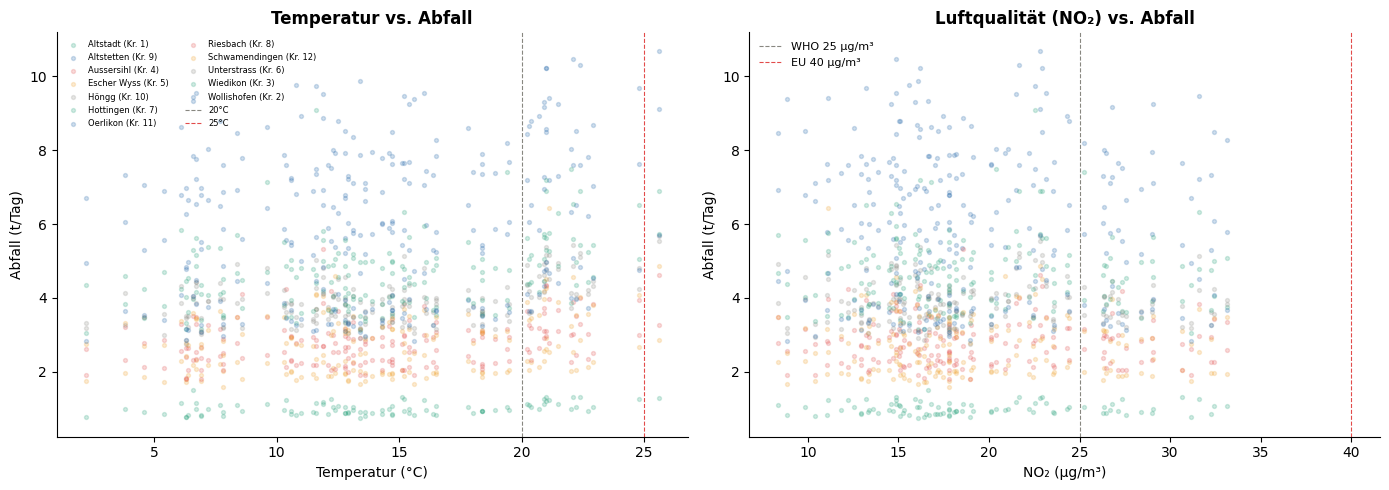

In [10]:
# Zwei Streudiagramme (Scatter Plots):
# 1. Temperatur vs. Abfall – zeigt den Temperatureffekt
# 2. NO₂ vs. Abfall – zeigt Korrelation mit Luftqualität


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
farben = list(COLORS.values()) * 4


# --- Diagramm 1: Temperatur vs. Abfall ---
for i, (bez, g) in enumerate(df.groupby('stadtkreis')):
    # scatter(): Streudiagramm (jeder Punkt = ein Tag × ein Stadtkreis)
    # s=8: Punktgrösse (klein, weil viele Punkte)
    axes[0].scatter(g['temperatur'], g['abfall_t'],
                    alpha=0.2, # sehr transparent (viele überlappende Punkte)
                    s=8,
                    color=farben[i % len(farben)],
                    label=STADTKREIS_ANZEIGE.get(bez, bez))

# Vertikale Referenzlinien bei 20°C und 25°C
axes[0].axvline(20, color=COLORS['grau'], linestyle='--', linewidth=0.8, label='20°C')
axes[0].axvline(25, color=COLORS['rot'],  linestyle='--', linewidth=0.8, label='25°C')
axes[0].set_xlabel('Temperatur (°C)')
axes[0].set_ylabel('Abfall (t/Tag)')
axes[0].set_title('Temperatur vs. Abfall', fontweight='bold')
axes[0].legend(frameon=False, fontsize=6, ncol=2)


# --- Diagramm 2: NO₂ vs. Abfall ---
# 'no2_µg' in df.columns: prüft ob die Spalte existiert (könnte im Fallback fehlen)
if 'no2_µg' in df.columns:
    for i, (bez, g) in enumerate(df.groupby('stadtkreis')):
        axes[1].scatter(g['no2_µg'], g['abfall_t'],
                        alpha=0.2, s=8,
                        color=farben[i % len(farben)])

    # WHO-Grenzwert 25 µg/m³ und EU-Grenzwert 40 µg/m³
    axes[1].axvline(25, color=COLORS['grau'], linestyle='--', linewidth=0.8, label='WHO 25 µg/m³')
    axes[1].axvline(40, color=COLORS['rot'],  linestyle='--', linewidth=0.8, label='EU 40 µg/m³')
    axes[1].set_xlabel('NO₂ (µg/m³)')
    axes[1].set_ylabel('Abfall (t/Tag)')
    axes[1].set_title('Luftqualität (NO₂) vs. Abfall', fontweight='bold')
    axes[1].legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()


---
## 8. Korrelationsanalyse

Im nächsten Schritt wollen wir wissen, wie stark unsere Variablen tatsächlich zusammenhängen. Dafür berechnen wir die Pearson-Korrelation, die für jedes Variablenpaar einen Wert zwischen -1 und +1 liefert und damit die Stärke und Richtung des linearen Zusammenhangs beschreibt:

| Wert | Bedeutung |
|------|-----------|
| +0.7 bis +1.0 | starke positive Korrelation |
| +0.3 bis +0.7 | moderate positive Korrelation |
| -0.1 bis +0.1 | kein nennenswerter Zusammenhang |
| -0.3 bis -1.0 | negative Korrelation (gegensätzliche Richtung) |

Auf Basis unserer Datenkonstruktion erwarten wir bestimmte Zusammenhänge mit der Zielvariable `abfall_t`. So sollte `ist_wochenende` stark positiv korrelieren, weil wir den Samstag und Sonntag bewusst mit höheren Multiplikatoren ausgestattet haben. Auch die `temperatur` sollte positiv mit der Abfallmenge zusammenhängen (mehr Aussenaktivitäten bei Wärme), während `niederschlag` negativ korrelieren dürfte, weil Regen die Aktivitäten nach drinnen verlagert. `hat_event` sollte ebenfalls positiv ausfallen, da Events das Aufkommen pro Stadtkreis um 30 bis 55 Prozent erhöhen. Bei `no2_µg` rechnen wir mit einer leicht positiven Korrelation, weil beide Werte mit dem allgemeinen Aktivitätsniveau steigen. Der `wochentag` als blosse Zahl sollte hingegen nur einen schwachen linearen Zusammenhang zeigen, weil das Muster nicht monoton ist (Wochenmitte tief, Samstag hoch).

Mit der Korrelationsanalyse prüfen wir also, ob unsere im Datengenerator hinterlegten Annahmen (Samstag x1.28, Hitzetag x1.20 und so weiter) im Datensatz auch wirklich angekommen sind. Anschliessend visualisieren wir die Korrelationen als Heatmap, in der jedes Feld den Korrelationswert zwischen zwei Variablen einfärbt; die Diagonale hat dabei immer einen Wert von 1, weil jede Variable mit sich selbst perfekt korreliert.

### Zum Beachten

* **Korrelation ist nicht gleich Kausalität.** Eine hohe Temperatur verursacht nicht direkt mehr Abfall, sie korreliert mit Freizeitverhalten, das wiederum mehr Abfall erzeugt. Ein klassisches Beispiel ist der Zusammenhang zwischen Eis- und Sonnenbrillenverkäufen: Beide steigen im Sommer, aber Sonnenbrillen verursachen keinen Eiskonsum. Statistik findet Zusammenhänge, sie beweist aber keine Ursachen.


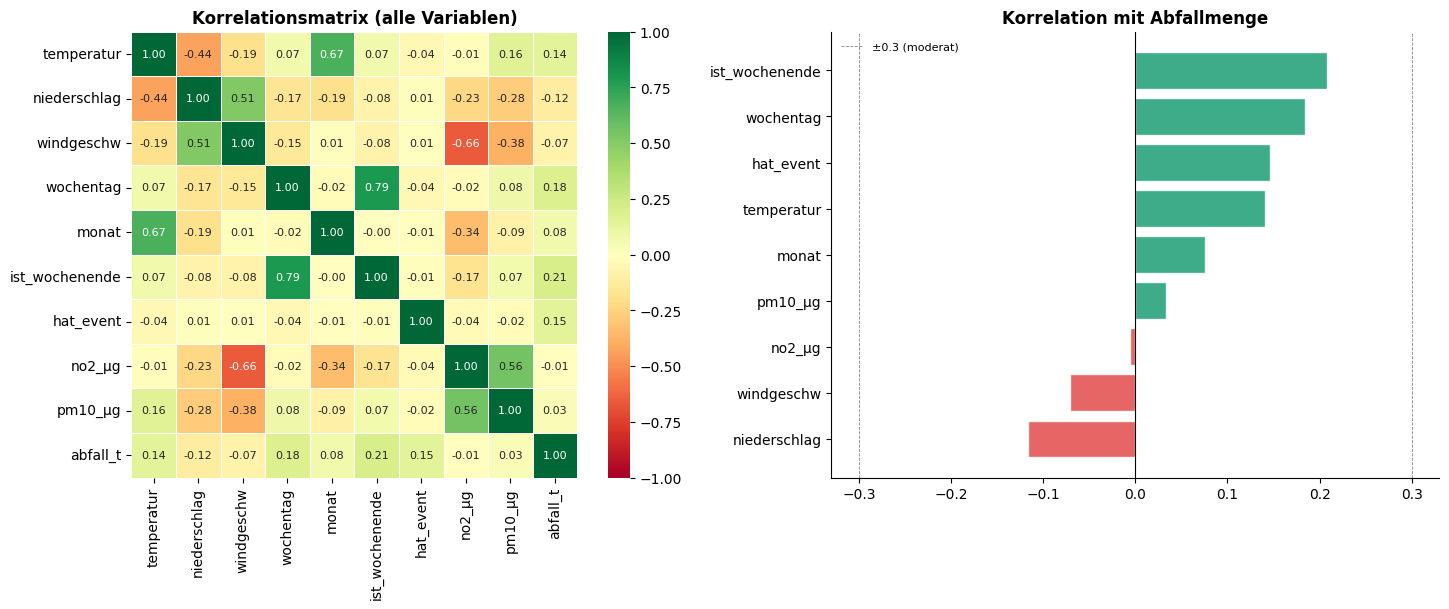


 Interpretation der stärksten Korrelationen
  ist_wochenende      : r=+0.21  [schwach, positiv]
  wochentag           : r=+0.18  [schwach, positiv]
  hat_event           : r=+0.15  [schwach, positiv]
  temperatur          : r=+0.14  [schwach, positiv]
  niederschlag        : r=-0.12  [schwach, negativ]


In [11]:
# Korrelationsmatrix berechnen und visualisieren:
# 1. Heatmap: alle Korrelationen als Farbtabelle
# 2. Balkendiagramm: nur Korrelationen mit der Zielvariable abfall_t
# Interpretationstext für die stärksten Korrelationen ausgeben.


# Spalten für die Korrelationsanalyse auswählen
# Nur numerische Spalten, die inhaltlich relevant sind
korr_spalten = ['temperatur', 'niederschlag', 'windgeschw', 'wochentag', 'monat',
                'ist_wochenende', 'hat_event', 'no2_µg', 'pm10_µg', 'abfall_t']

# Nur Spalten behalten die tatsächlich im DataFrame existieren (Fallback-Schutz)
# List Comprehension: [c for c in liste if bedingung]
korr_spalten = [c for c in korr_spalten if c in df.columns]

# .corr(): berechnet die Pearson-Korrelationsmatrix
# Ergebnis: quadratische Tabelle (Spalten × Spalten), Werte zwischen -1 und +1
korr = df[korr_spalten].corr()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))


# --- Diagramm 1: Korrelations-Heatmap ---
# sns.heatmap(): Seaborn-Funktion für farbcodierte Tabellen
# annot=True: Zahlen in den Feldern anzeigen
# fmt='.2f': 2 Dezimalstellen
# cmap='RdYlGn': Farbe Rot (negativ) -> Gelb (0) -> Grün (positiv)
# center=0: Farbskala bei 0 zentrieren
# square=True: quadratische Felder
# linewidths=0.5: dünne Linien zwischen Feldern
# vmin=-1, vmax=1: Farbskala von -1 bis +1 (nicht automatisch)
sns.heatmap(korr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            square=True, ax=axes[0], linewidths=0.5,
            annot_kws={'size': 8}, vmin=-1, vmax=1)
axes[0].set_title('Korrelationsmatrix (alle Variablen)', fontweight='bold')


# --- Diagramm 2: Korrelation speziell mit abfall_t ---
# korr['abfall_t']: Spalte 'abfall_t' aus der Korrelationsmatrix (Korrelation aller anderen mit Abfall)
# .drop('abfall_t'): Selbstkorrelation (r=1.0) entfernen
# .sort_values(): aufsteigend sortieren (negativste zuerst)
korr_abfall = korr['abfall_t'].drop('abfall_t').sort_values()

# List Comprehension: Farbe pro Balken je nach Vorzeichen
# v < 0 -> rot (negative Korrelation), sonst grün
farben_b = [COLORS['rot'] if v < 0 else COLORS['grün'] for v in korr_abfall]

# .barh(): horizontales Balkendiagramm
# range(len(korr_abfall)): Positionen 0, 1, 2, ...
# korr_abfall.values: numpy-Array der Korrelationswerte
axes[1].barh(range(len(korr_abfall)), korr_abfall.values,
             color=farben_b, alpha=0.85, edgecolor='white')

# Y-Achse: Variablennamen statt Zahlen anzeigen
axes[1].set_yticks(range(len(korr_abfall)))
axes[1].set_yticklabels(korr_abfall.index)

# Nulllinie und Orientierungslinien
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].axvline( 0.3, color=COLORS['grau'], linestyle='--', linewidth=0.6, label='±0.3 (moderat)')
axes[1].axvline(-0.3, color=COLORS['grau'], linestyle='--', linewidth=0.6)
axes[1].set_title('Korrelation mit Abfallmenge', fontweight='bold')
axes[1].legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()


# --- Textuelle Interpretation ---
print('\n Interpretation der stärksten Korrelationen')

# .sort_values(key=abs, ascending=False): sortiert nach absolutem Wert (stärkste zuerst)
# key=abs: verwendet die Funktion abs() als Sortierschlüssel
for var, val in korr_abfall.sort_values(key=abs, ascending=False).items():
    if abs(val) > 0.10:  # nur Korrelationen > 10% anzeigen
        richtung = 'positiv' if val > 0 else 'negativ'
        staerke  = 'stark' if abs(val) > 0.5 else 'moderat' if abs(val) > 0.3 else 'schwach'
        print(f'  {var:20s}: r={val:+.2f}  [{staerke}, {richtung}]')


---
## 9. Feature Engineering

Ein Machine-Learning-Modell versteht keine Wörter oder abstrakten Konzepte, sondern nur Zahlen. Im Feature Engineering bringen wir unsere Rohdaten deshalb in eine Form, die das Modell gut verarbeiten kann, und ergänzen sie um zusätzliche berechnete Spalten, die bestimmte Muster explizit hervorheben.

Konkret erzeugen wir drei Arten von Features. Erstens binäre Flags wie `hitzetag` oder `regentag`, die einen kontinuierlichen Wert in eine 0/1-Variable übersetzen. Damit kann das Modell einen Schwellenwerteffekt direkt lernen, ohne ihn aus der Temperatur erst herleiten zu müssen. Wir behalten die Temperatur trotzdem als Feature, weil sich die beiden Darstellungen ergänzen. Zweitens kodieren wir die Saisonalität zyklisch über `saison_sin` und `saison_cos`. Würden wir den Monat einfach als Zahl von 1 bis 12 verwenden, dann wären Dezember (12) und Januar (1) für das Modell rechnerisch weit voneinander entfernt, obwohl sie inhaltlich direkt nebeneinanderliegen. Sinus und Kosinus lösen das Problem, indem sie den Jahresverlauf auf einen Kreis legen, auf dem Dezember und Januar tatsächlich benachbart sind. Drittens wandeln wir den Stadtkreisnamen in einen numerischen Code um, weil ein Random Forest mit Strings nichts anfangen kann. Mit `pd.Categorical(..., categories=list(STADTKREISE.keys()))` fixieren wir dabei die Reihenfolge, sodass Altstadt immer den Code 0, Wollishofen immer 1 und so weiter erhält.


In [12]:
# Rohdaten (df) um neue berechnete Spalten erweitern ("Features").
# Diese Features helfen dem ML-Modell Muster besser zu erkennen.


def features_erstellen(df):
    '''Rohdaten in ML-Features umwandeln.

    Eingabe: df – DataFrame mit Rohdaten
    Ausgabe: neue Kopie des DataFrames mit zusätzlichen Feature-Spalten
    '''
    # .copy(): erstellt eine unabhängige Kopie des DataFrames
    # Wichtig: ohne .copy() würden wir das Original verändern (sogenannte "side effects")
    d = df.copy()


    # --- Temperatur-Flags ---
    # (d['temperatur'] > 25): Serie von True/False für jede Zeile
    # .astype(int): wandelt True -> 1, False -> 0 um
    d['hitzetag']   = (d['temperatur'] > 25).astype(int)

    # "warmer Tag": über 20°C ABER nicht über 25°C (dann wäre es ein Hitzetag)
    # & = logisches UND (für Serien/Arrays, nicht 'and' was nur für einzelne Werte gilt)
    d['warmer_tag'] = ((d['temperatur'] > 20) & (d['temperatur'] <= 25)).astype(int)


    # --- Niederschlag-Flags ---
    d['regentag']   = (d['niederschlag'] > 5).astype(int) # > 5mm = "Regentag"
    d['starkregen'] = (d['niederschlag'] > 15).astype(int) # > 15mm = "Starkregen"


    # --- Wochentag-Flags ---
    # wochentag: 0=Mo, 1=Di, 2=Mi, 3=Do, 4=Fr, 5=Sa, 6=So
    d['ist_freitag'] = (d['wochentag'] == 4).astype(int)
    d['ist_samstag'] = (d['wochentag'] == 5).astype(int)


    # --- Luftqualitäts-Flag ---
    # 'in d.columns' prüft ob die Spalte existiert (bei Fallback fehlt sie evtl.)
    if 'no2_µg' in d.columns:
        d['schlechte_luft'] = (d['no2_µg'] > 40).astype(int)  # > 40 µg/m³ = über EU-Limit


    # --- Zyklische Saisonalität ---
    # .dt.dayofyear: Tagesnummer im Jahr (1–365)
    t = d['datum'].dt.dayofyear

    # np.sin(2π × t / 365): eine volle Sinuswelle pro Jahr
    # Bei Tag 1 (1. Jan): sin(2π/365) ≈ 0.017 (nah an 0)
    # Bei Tag 91 (1. April): sin(π/2) = 1.0 (Maximum)
    # Bei Tag 183 (Mitte Jahr): sin(π) ≈ 0 (wieder 0)
    d['saison_sin'] = np.sin(2 * np.pi * t / 365)

    # np.cos(): 90° versetzt zu sin -> zusammen beschreiben sie einen Punkt auf dem Kreis
    # Mit beiden (sin UND cos) weiss das Modell eindeutig, wo im Jahr wir sind
    d['saison_cos'] = np.cos(2 * np.pi * t / 365)


    # --- Stadtkreis als numerischer Code ---
    # pd.Categorical(serie, categories=reihenfolge): wandelt Text in eine geordnete kategorische Variable um
    # .codes: gibt die Nummer jeder Kategorie zurück (0, 1, 2, ...)
    # categories=list(STADTKREISE.keys()): fixiert die Reihenfolge, damit 'Altstadt' immer Code 0 hat, 'Wollishofen' immer Code 1, usw.
    d['stadtkreis_code'] = pd.Categorical(d['stadtkreis'],
                                          categories=list(STADTKREISE.keys())).codes

    return d


# Feature Engineering auf den kombinierten DataFrame anwenden
df = features_erstellen(df)
print(f'OK Feature Engineering: {len(df.columns)} Spalten total')


OK Feature Engineering: 23 Spalten total


---
## 10. ML-Modell: Random Forest

Für die eigentliche Prognose haben wir uns für einen Random Forest entschieden. Ein Random Forest, also ein "zufälliger Wald", besteht aus vielen einzelnen Entscheidungsbäumen, die jeder für sich ein einfaches Ja/Nein-Fragenspiel sind ("Ist es Samstag? Ja. Ist es warm? Ja. Prognose: 7.2 Tonnen."). Indem viele leicht unterschiedliche Bäume gemeinsam abstimmen, wird das Ergebnis stabiler als bei einem einzelnen Baum. Da wir eine Zahl (Tonnen Abfall) und keine Kategorie vorhersagen, verwenden wir die Regressionsvariante `RandomForestRegressor`.

Dieses Modell passt aus mehreren Gründen gut zu unserem Problem. Es kommt mit numerischen und kategorischen Features ohne Normalisierung zurecht, es ist robust gegenüber Ausreissern, und es liefert eine Feature Importance, mit der wir später erklären können, welche Variablen am stärksten zur Prognose beigetragen haben.

Beim Aufteilen der Daten in Trainings- und Testset müssen wir bei Zeitreihen besonders aufpassen. Ein zufälliger Split, wie er bei vielen ML-Aufgaben üblich ist, würde bei uns sogenanntes Data Leakage verursachen: Wenn der 14. März im Test landet, der 15. März aber im Training, dann hätte das Modell die "Zukunft" gesehen und das Ergebnis wäre unrealistisch gut. Wir splitten deshalb chronologisch: Die ersten 80 Prozent der Daten verwenden wir zum Trainieren, die letzten 20 Prozent zum Testen. Das simuliert den späteren Produktiveinsatz, in dem das Modell auf vergangenen Daten trainiert wird und auf zukünftige Tage angewendet werden soll.

Zusätzlich setzen wir eine 5-fache Kreuzvalidierung ein. Dabei wird das Trainingsset fünfmal in unterschiedliche Train- und Validierungsteile aufgeteilt, sodass wir fünf unabhängige R²-Werte erhalten. Der Mittelwert dieser fünf Werte zeigt uns, wie stabil das Modell ist und ob wir mit einem einzelnen Split nur "Glück" hatten.


In [13]:
# Feature-Liste definieren und Daten in Trainings- und Testset aufteilen.
# Chronologischer Split: erste 80% = Training, letzte 20% = Test.


# --- Alle möglichen Features ---
# Diese Liste enthält alle Features, die wir dem Modell geben WOLLEN (nicht alle müssen existieren – manche fehlen beim Fallback)
ALLE_FEATURES = [
    # Wetter-Features (kontinuierlich)
    'temperatur', 'niederschlag', 'windgeschw',
    # Zeitliche Features
    'wochentag', 'monat', 'ist_wochenende', 'ist_freitag', 'ist_samstag',
    # Temperatur-Flags
    'hitzetag', 'warmer_tag',
    # Niederschlag-Flags
    'regentag', 'starkregen',
    # Event und Saison
    'hat_event', 'saison_sin', 'saison_cos',
    # Stadtkreis (numerisch kodiert)
    'stadtkreis_code',
    # Luftqualität
    'no2_µg', 'pm10_µg', 'schlechte_luft',
]

# Nur Features behalten, die tatsächlich im DataFrame vorhanden sind
# List Comprehension: filtert die Liste
FEATURES = [f for f in ALLE_FEATURES if f in df.columns]


# --- Chronologischer Train/Test-Split ---
# .sort_values('datum'): nach Datum sortieren (älteste zuerst)
# .reset_index(drop=True): Index neu von 0 nummerieren
df_sort = df.sort_values('datum').reset_index(drop=True)

# split-Index: 80% der Datenmenge
# int(): rundet ab (keine Dezimalstellen im Index möglich)
split = int(len(df_sort) * 0.8)

# .iloc[start:ende]: Integer-Location-Indexing (nach Zeilennummer, nicht Datumswert)
# .iloc[:split] = Zeilen 0 bis split-1 (Training)
# .iloc[split:] = Zeilen split bis Ende (Test)
X_train = df_sort[FEATURES].iloc[:split] # Feature-Matrix für Training
y_train = df_sort['abfall_t'].iloc[:split] # Zielvariable für Training

X_test  = df_sort[FEATURES].iloc[split:] # Feature-Matrix für Test
y_test  = df_sort['abfall_t'].iloc[split:] # Zielvariable für Test

# Kontrolle: Datumsgrenze des Splits ausgeben
print(f'Train: {len(X_train)} Zeilen bis {df_sort.iloc[split-1]["datum"].date()}')
print(f'Test:  {len(X_test)} Zeilen ab  {df_sort.iloc[split]["datum"].date()}')
print(f'Features ({len(FEATURES)}): {FEATURES}')


Train: 873 Zeilen bis 2026-04-25
Test:  219 Zeilen ab  2026-04-25
Features (19): ['temperatur', 'niederschlag', 'windgeschw', 'wochentag', 'monat', 'ist_wochenende', 'ist_freitag', 'ist_samstag', 'hitzetag', 'warmer_tag', 'regentag', 'starkregen', 'hat_event', 'saison_sin', 'saison_cos', 'stadtkreis_code', 'no2_µg', 'pm10_µg', 'schlechte_luft']


In [14]:
# Random Forest Modell konfigurieren, trainieren und mit Kreuzvalidierung prüfen.


# --- Modell konfigurieren ---
# RandomForestRegressor: ein Random Forest für Regressionsprobleme (Zahlen vorhersagen)
# Hyperparameter (Einstellungen, die wir manuell wählen):
modell = RandomForestRegressor(
    n_estimators=300, # 300 Entscheidungsbäume im Wald
                      # Mehr Bäume = stabiler, aber langsamer
                      # 300 ist ein gutes Gleichgewicht

    max_depth=10,     # Maximale Tiefe jedes Baums = 10 Entscheidungsebenen
                      # Begrenzt die Komplexität -> verhindert Overfitting
                      # Overfitting: Modell "lernt" die Trainingsdaten auswendig -> funktioniert auf Testdaten schlecht

    min_samples_leaf=3, # Jedes Blatt (Endknoten) muss mind. 3 Datenpunkte haben
                        # Verhindert dass einzelne Ausreisser eigene Knoten bilden

    max_features='sqrt', # Bei jedem Split: nur sqrt(n_features) zufällige Features prüfen Standard-Einstellung für Regression
                         # Zufälligkeit macht die Bäume unkorreliert -> besser als Ensemble

    random_state=42, # Festgelegter Zufallsseed für Reproduzierbarkeit
    n_jobs=-1        # Alle CPU-Kerne nutzen (n_jobs=-1 = alle verfügbaren)
)


# --- Modell trainieren ---
# .fit(X, y): das eigentliche "Lernen"
# X_train = Feature-Matrix (Eingaben), y_train = Zielvariable (Ausgaben)
# Das Modell sucht nach Mustern: Welche Feature-Kombinationen sagen welches y vorher?
modell.fit(X_train, y_train)


# --- Kreuzvalidierung (Cross-Validation) ---
# cross_val_score(): teilt X_train 5× auf, trainiert jeweils auf 4 Teilen
# und validiert auf dem 5. Teil. Gibt 5 R²-Werte zurück.
# scoring='r2': R² als Bewertungsmetrik
# cv=5: 5-fach Kreuzvalidierung (5-fold cross-validation)
cv = cross_val_score(modell, X_train, y_train, cv=5, scoring='r2')


print(f'OK Modell trainiert')
# cv.mean(): Durchschnitt der 5 R²-Werte
# cv.std(): Standardabweichung (zeigt Stabilität: kleiner = konsistenter)
print(f'  Kreuzvalidierung R² (5-fold): {cv.mean():.3f} ± {cv.std():.3f}')


OK Modell trainiert
  Kreuzvalidierung R² (5-fold): 0.614 ± 0.032


---
## 11. Modell-Evaluation

Um zu beurteilen, wie gut unser Modell tatsächlich ist, reicht uns ein einzelner Wert nicht aus. Wir berechnen vier Kennzahlen, die jeweils einen anderen Aspekt der Prognosegüte beleuchten:

| Metrik | Bedeutung |
|--------|-----------|
| **MAE** | durchschnittlicher absoluter Fehler in Tonnen, direkt interpretierbar |
| **RMSE** | bestraft grosse Ausreisser stärker als der MAE |
| **R²** | Anteil der erklärten Varianz; 1.0 ist perfekt, 0 entspricht dem Mittelwert |
| **MAPE** | durchschnittlicher Fehler in Prozent |

Der MAE (Mean Absolute Error) sagt uns auf einen Blick, um wie viele Tonnen die Prognose im Schnitt danebenliegt; ein MAE von 0.3 bedeutet schlicht "im Mittel liegen wir 0.3 Tonnen daneben". Der RMSE (Root Mean Squared Error) folgt derselben Idee, quadriert die Fehler aber zuerst, bevor er die Wurzel zieht. Dadurch fallen einzelne grosse Fehler stärker ins Gewicht. Wenn der RMSE deutlich grösser als der MAE ist, gibt es im Datensatz also einzelne Ausreisser-Prognosen. Das R² (Bestimmtheitsmass) drückt aus, welcher Anteil der Schwankung in der Zielvariable durch unsere Features erklärt wird; ein R² von 0.85 heisst, dass das Modell 85 Prozent der Variation erklärt. Der MAPE schliesslich gibt den Fehler in Prozent an und ist nützlich, um die Modellgüte zwischen den Stadtkreisen zu vergleichen, weil diese sehr unterschiedliche Absolutgrössen haben.

Damit wir einschätzen können, ob das Modell überhaupt etwas Sinnvolles gelernt hat, vergleichen wir es zusätzlich mit einem Basismodell, das einfach immer den Mittelwert vorhersagt. Das ist die naivste mögliche Prognose. Ist unser ML-Modell nicht besser als diese Baseline, dann hat es nichts gelernt. Der prozentuale Verbesserungswert zeigt, welchen Mehrwert das Modell tatsächlich bringt.

Wichtig ist, dass die ganze Evaluation auf den Testdaten stattfindet, die das Modell beim Training nie gesehen hat. Nur auf solchen ungesehenen Daten zeigt sich, ob das Modell wirklich Muster gelernt oder nur die Trainingsdaten auswendig gelernt hat. Letzteres nennt man Overfitting.


In [15]:
# Modell auf Testdaten anwenden und vier Qualitätsmetriken berechnen.
# Vergleich mit dem "Basismodell" (immer Mittelwert vorhersagen).


# --- Prognose auf Testdaten ---
# .predict(X): wendet das trainierte Modell auf neue Daten an
# X_test hat das Modell nie gesehen -> ehrlicher Test
# y_pred = numpy-Array mit vorhergesagten Werten (eine Zahl pro Zeile)
y_pred = modell.predict(X_test)


# --- Qualitätsmetriken berechnen ---
# y_test = echte Werte (bekannt), y_pred = vorhergesagte Werte (Modell)

# MAE: Durchschnitt der absoluten Differenzen |echt - vorhergesagt|
mae  = mean_absolute_error(y_test, y_pred)

# RMSE: Wurzel des quadratischen Fehlers
# mean_squared_error = Durchschnitt von (echt - vorhergesagt)²
# np.sqrt(): Quadratwurzel
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# R²: 1 - (Varianz Fehler) / (Varianz Daten)
r2   = r2_score(y_test, y_pred)

# MAPE: Durchschnitt von |echt - vorhergesagt| / echt × 100%
# .values: numpy-Array aus pandas-Serie
# np.abs(): Absolutwert
# np.mean(): Durchschnitt
mape = np.mean(np.abs((y_test.values - y_pred) / y_test.values)) * 100


# --- Basismodell (Baseline) ---
# Das naivste Modell: sagt IMMER den Durchschnitt (y_test.mean()) voraus
# [y_test.mean()] * len(y_test): Liste mit len(y_test) identischen Werten
basis_mae = mean_absolute_error(y_test, [y_test.mean()] * len(y_test))

# Ergebnisse ausgeben
print('  MODELL-EVALUATION (ungesehene Testdaten)')
print(f'  MAE    {mae:.3f} t <- durchschnittlicher Fehler')
print(f'  RMSE   {rmse:.3f} t <- bestraft Ausreisser stärker')
print(f'  R²     {r2:.3f} <- Anteil erklärter Varianz')
print(f'  MAPE   {mape:.1f}% <- Fehler in Prozent')
print(f'')
print(f'  Basismodell (immer Ø): MAE = {basis_mae:.3f} t')

# Verbesserung: (1 - mae/basis_mae) × 100%
# Wenn MAE des Modells = 0.3t, Baseline = 1.0t -> (1 - 0.3/1.0) × 100 = 70% besser
print(f'  Verbesserung durch ML: {(1 - mae / basis_mae) * 100:.1f}%')
print(f'')

# Qualitätsbewertung
if   r2 > 0.80: print('\nOK Starke Prognosequalitaet (R2 > 0.80)')
elif r2 > 0.60: print('\nOK Gute Prognosequalitaet (R2 > 0.60)')
else:           print('\nWARNUNG: Schwache Prognosequalitaet – mehr Features noetig')


  MODELL-EVALUATION (ungesehene Testdaten)
  MAE    1.118 t <- durchschnittlicher Fehler
  RMSE   1.364 t <- bestraft Ausreisser stärker
  R²     0.563 <- Anteil erklärter Varianz
  MAPE   40.0% <- Fehler in Prozent

  Basismodell (immer Ø): MAE = 1.573 t
  Verbesserung durch ML: 29.0%


WARNUNG: Schwache Prognosequalitaet – mehr Features noetig


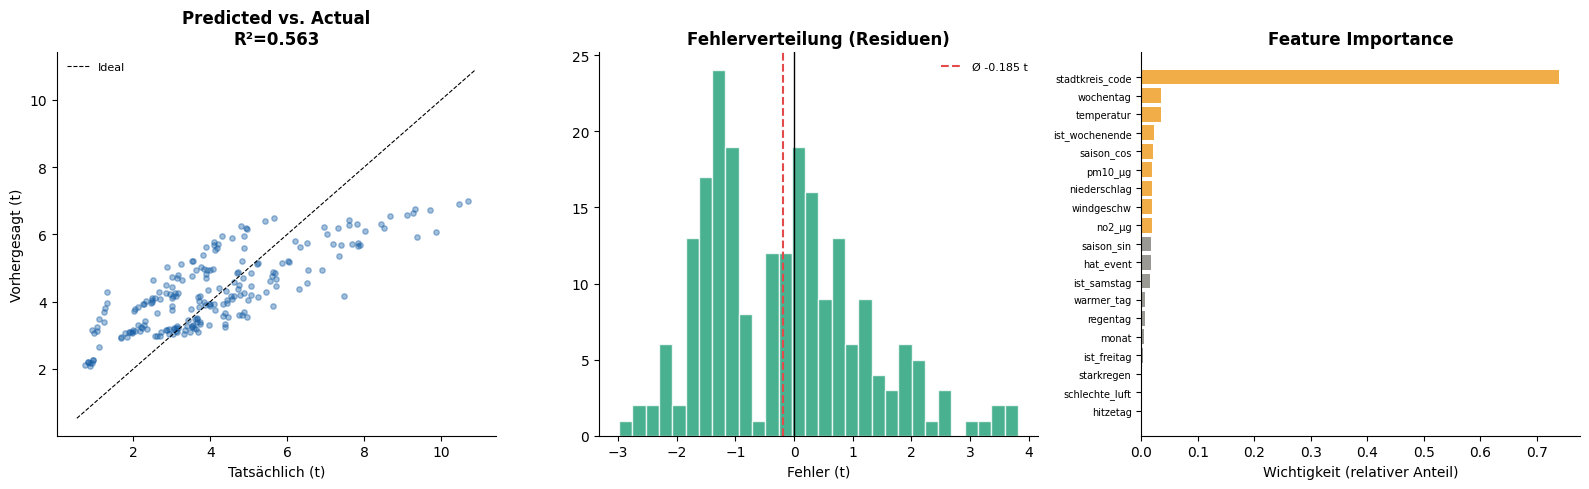

In [16]:
# Drei Evaluationsdiagramme nebeneinander:
# 1. Predicted vs. Actual: Punkte sollten auf der Diagonalen liegen
# 2. Residuen-Histogramm: Fehlerverteilung (sollte normalverteilt sein)
# 3. Feature Importance: welche Variablen helfen dem Modell am meisten?


fig, axes = plt.subplots(1, 3, figsize=(16, 5))


# --- Diagramm 1: Predicted vs. Actual ---
# Jeder Punkt: x = echter Wert, y = vorhergesagter Wert
# Ideales Modell: alle Punkte auf der Linie y=x
axes[0].scatter(y_test, y_pred, alpha=0.4, s=15, color=COLORS['blau'])

# Ideallinie (Diagonale): min bis max, slope=1
lims = [min(y_test.min(), y_pred.min()) - 0.2,
        max(y_test.max(), y_pred.max()) + 0.2]
axes[0].plot(lims, lims, 'k--', linewidth=0.8, label='Ideal')
axes[0].set_xlabel('Tatsächlich (t)')
axes[0].set_ylabel('Vorhergesagt (t)')
axes[0].set_title(f'Predicted vs. Actual\nR²={r2:.3f}', fontweight='bold')
axes[0].legend(frameon=False, fontsize=8)


# --- Diagramm 2: Residuen-Verteilung ---
# Residuen = tatsächlich - vorhergesagt
# Bei einem guten Modell: normalverteilt um 0 (kein systematischer Fehler)
resid = y_test.values - y_pred

axes[1].hist(resid, bins=30, color=COLORS['grün'], alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1)  # Nulllinie

# Durchschnittlicher Fehler (sollte nahe 0 sein – kein systematischer Bias)
axes[1].axvline(resid.mean(), color=COLORS['rot'], linewidth=1.5, linestyle='--',
                label=f'Ø {resid.mean():.3f} t')
axes[1].set_title('Fehlerverteilung (Residuen)', fontweight='bold')
axes[1].set_xlabel('Fehler (t)')
axes[1].legend(frameon=False, fontsize=8)


# --- Diagramm 3: Feature Importance ---
# modell.feature_importances_: numpy-Array mit der Wichtigkeit jedes Features (0 bis 1, Summe=1)
# pd.Series(..., index=FEATURES): erstellt eine benannte Serie (Wert + Name)
# .sort_values(): aufsteigend sortieren (unwichtigste zuerst -> links im barh-Plot)
importance = pd.Series(modell.feature_importances_, index=FEATURES).sort_values()

# Farbe: über Median = gelb (wichtig), unter Median = grau (weniger wichtig)
farben_fi = [COLORS['gelb'] if v > importance.median() else COLORS['grau'] for v in importance]

axes[2].barh(range(len(importance)), importance.values, color=farben_fi, alpha=0.85)
axes[2].set_yticks(range(len(importance)))
axes[2].set_yticklabels(importance.index, fontsize=7)
axes[2].set_title('Feature Importance', fontweight='bold')
axes[2].set_xlabel('Wichtigkeit (relativer Anteil)')

plt.tight_layout()
plt.show()


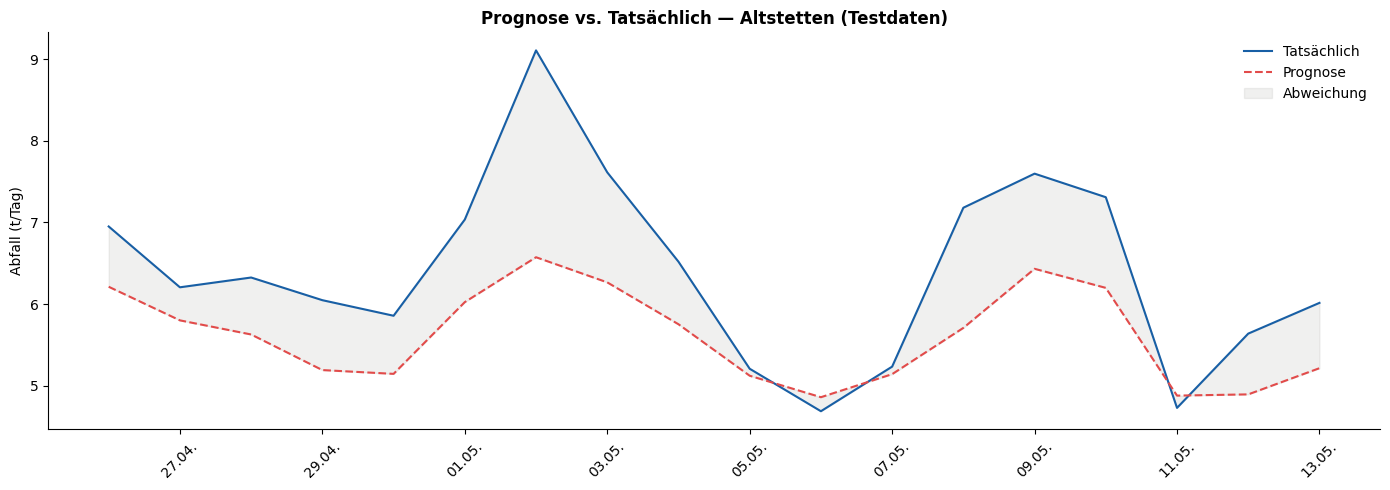

In [17]:
# Zeitverlauf der Prognose vs. tatsächliche Werte für einen spezifischen Stadtkreis (Altstetten, grösster Stadtkreis nach Fläche).
# Zeigt wie gut das Modell tagesweise prognostiziert.


# Testdaten als Kopie (damit wir 'prognose' hinzufügen können ohne df_sort zu verändern)
test_df = df_sort.iloc[split:].copy()

# Prognose-Spalte hinzufügen: y_pred enthält die Vorhersagen in gleicher Reihenfolge
test_df['prognose'] = y_pred

# Nur Altstetten filtern (grösster Stadtkreis nach Fläche, repräsentatives Beispiel)
# df[df['stadtkreis'] == 'Altstetten']: Boolean-Indexing – nur Zeilen wo Bedingung True
bsp = test_df[test_df['stadtkreis'] == 'Altstetten']

fig, ax = plt.subplots(figsize=(14, 5))

# Echte Werte: blaue Linie
ax.plot(bsp['datum'], bsp['abfall_t'],
        color=COLORS['blau'], linewidth=1.5, label='Tatsächlich')

# Prognose: rote gestrichelte Linie
ax.plot(bsp['datum'], bsp['prognose'],
        color=COLORS['rot'], linewidth=1.5, linestyle='--', label='Prognose')

# Bereich zwischen echter und vorhergesagter Linie grau füllen (= Fehlerbereich)
ax.fill_between(bsp['datum'], bsp['abfall_t'], bsp['prognose'],
                alpha=0.12, color=COLORS['grau'], label='Abweichung')

ax.set_title('Prognose vs. Tatsächlich — Altstetten (Testdaten)', fontsize=12, fontweight='bold')
ax.set_ylabel('Abfall (t/Tag)')
ax.legend(frameon=False)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m.'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


---
## 12. Export für die App: JSON mit kontextspezifischen Handlungsempfehlungen

Damit unsere WebApp die Prognose direkt anzeigen kann, exportieren wir die Ergebnisse in zwei JSON-Dateien (`waste_predictions.json` und `district_stats.json`). JSON ist das übliche Format für den Austausch zwischen einem Python-Backend und einem Frontend, und unsere App kann diese Dateien direkt einlesen.

Statt rohe Tonnenwerte an die App zu schicken, fassen wir die Prognose in eine vereinfachte Risikoampel mit den Stufen "normal", "mittel" und "hoch" zusammen. Das macht die Information für die Disponentinnen und Disponenten sofort lesbar, ohne dass sie Statistik interpretieren müssen. Die Ampelstufe berechnen wir bewusst aus der Abweichung vom historischen Durchschnitt des jeweiligen Stadtkreises und nicht aus dem Absolutwert. So sind 7 Tonnen in Oerlikon "normal", während dieselben 7 Tonnen in der Altstadt "extrem hoch" wären.

Zusätzlich generiert das System eine kontextspezifische Handlungsempfehlung. Dieselbe Stufe "hoch" kann ja unterschiedliche Ursachen haben (Hitze, Veranstaltung, Samstag), und je nach Auslöser braucht die Disposition andere Massnahmen. Wir kombinieren deshalb Risikostufe, Wetter, Eventstatus und Wochentag und geben einen passenden Hinweis aus.

Insgesamt deckt die Empfehlungslogik 12 verschiedene Hinweistypen ab:

| Bedingung | Empfehlung |
|-----------|-----------|
| hoch + Hitzetag >25°C | Frühschicht 05:30 (vor der Hitze), 1 Zusatzfahrzeug |
| hoch + Event im Stadtkreis | Routensperrungen prüfen, 2 Extrafahrzeuge, Event-Koordination |
| hoch + Samstag | 2 Fahrzeuge ab 06:00 |
| hoch + Sommer (Juli/August) | Grünabfall-Container prüfen, 1 Extrafahrzeug |
| hoch (allgemein) | 1 Zusatzfahrzeug und Überladestation vorinformieren |
| mittel + Regen >5mm | Nassabfall: Ladegewicht +8%, Tourkapazität anpassen |
| mittel + NO₂ >40 µg/m³ | schlechte Luftqualität, Elektro- oder Gasfahrzeug bevorzugen |
| mittel + Freitag | Wohngebiete ab 14:00 verstärkt anfahren |
| mittel + Sommer | Frühstart 06:00, Grünabfall beachten |
| mittel (allgemein) | Frühstart 06:00 empfohlen |
| normal + Montag | leicht erhöht nach Wochenende, Normalroute reicht |
| normal | Normalbetrieb, keine Anpassungen nötig |


In [18]:
# Hilfsfunktionen für den App-Export:
# - risikostufe(): berechnet die Ampelfarbe
# - app_text(): Kurztext für die App-Anzeige
# - empfehlung(): kontextspezifische Handlungsempfehlung
# - wetter_forecast(): 7-Tage-Wettervorhersage von Open-Meteo
# Dann: 7-Tage-Forecast berechnen und vorbereiten


def risikostufe(aktuell, durchschnitt):
    '''Abweichung vom Durchschnitt -> Risikostufe.

    Eingabe: aktuell (float) = heutiger Prognosewert, durchschnitt (float) = Normalwert
    Ausgabe: 'hoch', 'mittel' oder 'normal' (str)

    Berechnung:
      Abweichung = (aktuell - durchschnitt) / durchschnitt
      > 15%: hoch | > 5%: mittel | sonst: normal
    '''
    # Relative Abweichung berechnen (in Dezimalform, nicht Prozent)
    abw = (aktuell - durchschnitt) / durchschnitt
    return 'hoch' if abw > 0.15 else 'mittel' if abw > 0.05 else 'normal'


def app_text(risiko):
    '''Kurztext für App-Anzeige basierend auf Risikostufe.

    Eingabe: risiko (str) – 'hoch', 'mittel' oder 'normal'
    Ausgabe: Anzeigetext (str)

    Dictionary-Lookup: anstelle von if/elif/else ein Dictionary verwenden
    {'schluessel': 'wert'}[schluessel] -> gibt 'wert' zurück
    '''
    return {
        'hoch':   'Viel mehr als üblich',
        'mittel': 'Etwas mehr als üblich',
        'normal': 'Wie erwartet'
    }[risiko]


def empfehlung(risiko, stadtkreis, temp=20, regen=0, hat_event=0, wochentag=0, monat=6, no2=25):
    '''Kontextspezifische Handlungsempfehlung basierend auf mehreren Faktoren.

    Eingabe:
      risiko (str): 'hoch', 'mittel' oder 'normal'
      stadtkreis (str): Name des Stadtkreises (für Ausgabe)
      temp (float): Temperatur in °C
      regen (float): Niederschlag in mm
      hat_event (int): 1 wenn Event, 0 sonst
      wochentag (int): 0=Mo bis 6=So
      monat (int): 1=Jan bis 12=Dez
      no2 (float): NO₂-Konzentration in µg/m³
    Ausgabe: Empfehlungstext (str)

    Logik: Kaskadierende if/elif – wichtigste Situation zuerst prüfen
    '''
    if risiko == 'hoch':
        if hat_event:
            return f'{stadtkreis}: Veranstaltung – Routensperrungen prüfen, 2 Extrafahrzeuge einplanen'
        if temp > 25:
            return f'{stadtkreis}: Hitzebetrieb – Frühschicht 05:30 Uhr, 1 Zusatzfahrzeug'
        if wochentag == 5:
            return f'{stadtkreis}: Samstag-Hochbetrieb – 2 Fahrzeuge ab 06:00 Uhr'
        if monat in [7, 8]:
            return f'{stadtkreis}: Sommersaison – Grünabfall-Container prüfen, 1 Extrafahrzeug'
        return f'{stadtkreis}: Überkapazität – 1 Zusatzfahrzeug + Überladestation vorinformieren'

    if risiko == 'mittel':
        if regen > 5:
            return f'{stadtkreis}: Nassabfall – Ladegewicht ca. +8%, Tourkapazität anpassen'
        if no2 > 40:
            # f-String mit :.0f formatiert Zahl ohne Dezimalstellen
            return f'{stadtkreis}: Schlechte Luftqualität (NO₂={no2:.0f} µg/m³) – Elektro-/Gasfahrzeug bevorzugen'
        if wochentag == 4:
            return f'{stadtkreis}: Freitagseffekt – Wohngebiete ab 14:00 Uhr verstärkt anfahren'
        if monat in [7, 8]:
            return f'{stadtkreis}: Erhöhtes Aufkommen – Frühstart 06:00, Grünabfall beachten'
        return f'{stadtkreis}: Erhöhtes Aufkommen – Frühstart 06:00 Uhr empfohlen'

    # normal
    if wochentag == 0:
        return f'{stadtkreis}: Montag nach Wochenende – leicht erhöht, Normalroute ausreichend'
    return f'{stadtkreis}: Normalbetrieb – keine Anpassungen nötig'


def wetter_forecast():
    '''Open-Meteo Forecast-API: Wettervorhersage für die nächsten 7 Tage.

    Ausgabe: DataFrame mit Spalten datum, temperatur, niederschlag, windgeschw
    Falls API nicht erreichbar: letzte 7 Tage der historischen Daten als Fallback
    '''
    # Andere URL als Archiv-API: /v1/forecast statt /v1/archive
    url = ('https://api.open-meteo.com/v1/forecast'
           '?latitude=47.38&longitude=8.54'
           '&daily=temperature_2m_max,precipitation_sum,windspeed_10m_max'
           '&forecast_days=7&timezone=Europe/Zurich')
    try:
        r = requests.get(url, timeout=10)
        r.raise_for_status()
        d = r.json()['daily']
        return pd.DataFrame({
            'datum':        pd.to_datetime(d['time']),
            'temperatur':   d['temperature_2m_max'],
            'niederschlag': d['precipitation_sum'],
            'windgeschw':   d['windspeed_10m_max'],
        }).ffill()
    except:
        # Fallback: letzte 7 Tage der historischen Wetterdaten verwenden
        return wetter_df.tail(7).copy()


# --- 7-Tage-Forecast berechnen ---
# Wettervorhersage abrufen
fc_w = wetter_forecast()

# Synthetische Abfallmengen für Forecast-Wetterdaten berechnen
fc_a = abfall_generieren(fc_w, events_df)

# Feature Engineering auf Forecast anwenden
fc_a = features_erstellen(fc_a)

# Letzte bekannte Luftqualitätswerte aus dem historischen DataFrame
# float(): pandas kann manchmal eine Serie statt einer Zahl zurückgeben
# 30.0 bzw. 20.0: Fallback-Werte wenn Spalte nicht vorhanden
letzter_no2  = float(luftq_df['no2_µg'].iloc[-1])  if 'no2_µg'  in luftq_df.columns else 30.0
letzter_pm10 = float(luftq_df['pm10_µg'].iloc[-1]) if 'pm10_µg' in luftq_df.columns else 20.0

# Luftqualitätsspalten zum Forecast-DataFrame hinzufügen
for col, val in [('no2_µg', letzter_no2), ('pm10_µg', letzter_pm10)]:
    if col in FEATURES and col not in fc_a.columns:
        fc_a[col] = val  # Alle Zeilen bekommen denselben letzten bekannten Wert

# schlechte_luft-Flag setzen
if 'schlechte_luft' in FEATURES:
    fc_a['schlechte_luft'] = (fc_a.get('no2_µg', 30) > 40).astype(int)

# Modell auf Forecast-Daten anwenden: Prognose in Tonnen
fc_a['prognose_t'] = modell.predict(fc_a[FEATURES]).round(2)

# Durchschnittliche Abfallmenge pro Stadtkreis (aus Trainingsdaten)
# .groupby('stadtkreis')['abfall_t'].mean(): Mittelwert pro Stadtkreis
# .to_dict(): in Dictionary umwandeln {'Altstadt': 2.3, 'Oerlikon': 7.1, ...}
sk_avg = df_sort.iloc[:split].groupby('stadtkreis')['abfall_t'].mean().to_dict()

print('OK Forecast für 7 Tage bereit')


OK Forecast für 7 Tage bereit


In [19]:
# Aus den Forecast-Daten zwei JSON-Dateien erstellen:
# 1. waste_predictions.json: Prognose pro Tag × Stadtkreis (7 Tage)
# 2. district_stats.json: Zusammenfassung pro Stadtkreis (für Dashboard)


# Wochentagnamen auf Deutsch (Index entspricht datetime.weekday())
# 0=Montag, 1=Dienstag, ..., 6=Sonntag
wt_de = ['Mo', 'Di', 'Mi', 'Do', 'Fr', 'Sa', 'So']


# --- Prognose-Struktur aufbauen ---
predictions = [] # Leere Liste, wird mit einem Dictionary pro Tag gefüllt

# fc_a.groupby('datum'): gruppiert nach Datum
# Liefert (datum, sub_dataframe)-Paare
# tdf: alle Zeilen eines bestimmten Datums (alle 12 Stadtkreise)
for datum, tdf in fc_a.groupby('datum'):
    # Tages-Dictionary aufbauen
    tag = {
        'datum':     datum.strftime('%Y-%m-%d'), # Datum als ISO-String
        'wochentag': wt_de[datum.weekday()], # z.B. 'Sa'
        'wetter': {
            # .iloc[0]: erster Wert (alle Zeilen haben dasselbe Wetter)
            # round(..., 1): auf 1 Dezimalstelle runden
            'temperatur_c':    round(float(tdf['temperatur'].iloc[0]), 1),
            'niederschlag_mm': round(float(tdf['niederschlag'].iloc[0]), 1),
            'luftqualitaet':   luftq_ampel(letzter_no2),
        },
        'stadtkreise': [], # Liste der Stadtkreis-Daten für diesen Tag
    }

    # Für jeden Stadtkreis am diesem Tag
    # .iterrows(): liefert (index, zeile)-Paare
    for _, z in tdf.iterrows():
        b  = z['stadtkreis'] # Stadtkreisname
        p  = z['prognose_t'] # prognostizierte Tonnage

        # Durchschnitt aus Trainingsdaten (Normalwert für diesen Stadtkreis)
        # sk_avg.get(b, p): nimm sk_avg[b] oder p als Fallback wenn nicht vorhanden
        d  = sk_avg.get(b, p)
        ri = risikostufe(p, d)  # Ampel berechnen

        tag['stadtkreise'].append({
            'name':           b,
            'anzeige':        STADTKREIS_ANZEIGE.get(b, b),
            'prognose_t':     p,
            'normalwert_t':   round(d, 2),
            'abweichung_pct': round((p - d) / d * 100, 1), # % Abweichung
            'risikostufe':    ri,
            'anzeige_text':   app_text(ri),
            'empfehlung':     empfehlung(ri, b,
                                         temp=z['temperatur'],
                                         regen=z['niederschlag'],
                                         hat_event=int(z.get('hat_event', 0)),
                                         wochentag=int(z['wochentag']),
                                         monat=int(z['monat']),
                                         no2=letzter_no2),
        })

    predictions.append(tag)


# JSON-Datei schreiben
# 'w': write-Modus (überschreibt existierende Datei)
# encoding='utf-8': für Umlaute (ä, ö, ü)
# ensure_ascii=False: Umlaute direkt schreiben (nicht als \u00e4 codieren)
# indent=2: 2 Leerzeichen Einrückung (lesbar formatiertes JSON)
with open('waste_predictions.json', 'w', encoding='utf-8') as f:
    json.dump(predictions, f, ensure_ascii=False, indent=2)
print('OK waste_predictions.json gespeichert')


# --- Stadtkreis-Statistiken für Dashboard ---
stats = []

for stadtkreis in STADTKREISE:
    # Historische Daten für diesen Stadtkreis
    bd = df[df['stadtkreis'] == stadtkreis]

    # Historischer Durchschnitt
    avg = bd['abfall_t'].mean()

    # 14-Tage-Trend: Vergleich der letzten 14 Tage mit Gesamtdurchschnitt
    # .tail(14): letzte 14 Zeilen
    trend = round((bd.tail(14)['abfall_t'].mean() - avg) / avg * 100, 1)

    # Heutige Prognose aus predictions[0] (erster Tag = heute)
    # Generator mit next(): suche ersten Eintrag in der Liste wo 'name' == stadtkreis
    # Muster: next((element for element in liste if bedingung), fallback_wert)
    # Fallback: rund(avg, 2) wenn stadtkreis nicht in predictions[0] gefunden
    heute = next(
        (b['prognose_t'] for b in predictions[0]['stadtkreise'] if b['name'] == stadtkreis),
        round(avg, 2)
    )

    ri = risikostufe(heute, avg)

    stats.append({
        'stadtkreis':         stadtkreis,
        'anzeige':            STADTKREIS_ANZEIGE.get(stadtkreis, stadtkreis),
        # Hinweis: durchschnitt_t wird aus ALLEN 90 Tagen berechnet.
        # waste_predictions nutzt sk_avg (nur Trainingsdaten, ca. 80%) -> leicht andere Werte by design.
        'durchschnitt_t':     round(avg, 2),
        'heute_prognose_t':   heute,
        'trend_14tage_pct':   trend,
        'risikostufe':        ri,
        'anzeige_text':       app_text(ri),
        # Empfehlung aus predictions[0] wiederverwenden (enthaelt Wetter+Event-Kontext).
        # Direktes Neugenerieren ohne hat_event-Kontext erzeugt Inkonsistenz mit waste_predictions.
        'empfehlung':         (next((b['empfehlung'] for b in predictions[0]['stadtkreise']
                               if b['name'] == stadtkreis), None)
                               or empfehlung(ri, stadtkreis, no2=letzter_no2)),
        'luftqualitaet':      luftq_ampel(letzter_no2),
    })

with open('district_stats.json', 'w', encoding='utf-8') as f:
    json.dump(stats, f, ensure_ascii=False, indent=2)
print('OK district_stats.json gespeichert')

print('\nTagesüberblick:')
for d in stats:
    print(f"  {d['anzeige']:25s}  {d['heute_prognose_t']:.2f}t  {d['risikostufe']:6s}  {d['empfehlung']}")


OK waste_predictions.json gespeichert
OK district_stats.json gespeichert

Tagesüberblick:
  Altstadt (Kr. 1)           2.15t  hoch    Altstadt: Überkapazität – 1 Zusatzfahrzeug + Überladestation vorinformieren
  Wollishofen (Kr. 2)        3.41t  normal  Wollishofen: Montag nach Wochenende – leicht erhöht, Normalroute ausreichend
  Wiedikon (Kr. 3)           3.55t  normal  Wiedikon: Montag nach Wochenende – leicht erhöht, Normalroute ausreichend
  Aussersihl (Kr. 4)         3.09t  normal  Aussersihl: Montag nach Wochenende – leicht erhöht, Normalroute ausreichend
  Escher Wyss (Kr. 5)        3.03t  hoch    Escher Wyss: Überkapazität – 1 Zusatzfahrzeug + Überladestation vorinformieren
  Unterstrass (Kr. 6)        3.12t  normal  Unterstrass: Montag nach Wochenende – leicht erhöht, Normalroute ausreichend
  Hottingen (Kr. 7)          3.17t  normal  Hottingen: Montag nach Wochenende – leicht erhöht, Normalroute ausreichend
  Riesbach (Kr. 8)           3.17t  hoch    Riesbach: Überkapazität 

---
## 13. Risikokarte der Zürcher Stadtkreise

Damit man die Prognose nicht nur als Tabelle, sondern auch geografisch erfassen kann, erstellen wir eine interaktive Karte mit den zwölf Stadtkreisen. Jeder Stadtkreis wird je nach Risikostufe eingefärbt: grün steht für Normalbetrieb, gelb für ein erhöhtes Aufkommen mit Frühstart-Empfehlung und rot für Überkapazität, bei der Zusatzfahrzeuge nötig sind. Beim Klick auf einen Stadtkreis öffnet sich ein Tooltip mit Stadtkreisname, Prognose, Abweichung und der konkreten Empfehlung.

Für die Karte nutzen wir Folium, eine Python-Bibliothek, die im Hintergrund interaktive Leaflet.js-Karten generiert und sie direkt im Jupyter Notebook anzeigt. Die offiziellen Stadtkreisgrenzen holen wir uns als GeoJSON-Polygone vom WFS-Dienst der Stadt Zürich. WFS (Web Feature Service) ist dabei ein Standardprotokoll für geografische Daten, und GeoJSON ist ein JSON-Format, das die GPS-Punkte beschreibt, die den Umriss eines Stadtkreises bilden. Beides ist als Open Data der Stadt Zürich verfügbar (Datensatz [geo_stadtkreise](https://data.stadt-zuerich.ch/dataset/geo_stadtkreise)).

### Zum Beachten

* **Robustes Error-Handling:** Wir fangen drei Fehlerfälle separat ab, damit das Notebook auch bei Problemen klar kommuniziert, was schiefgegangen ist: `ImportError`, falls Folium nicht installiert ist, `RequestException` bei Netzwerkproblemen und ein generisches `Exception` für alles andere.
* **Schneller Lookup über Dictionary:** Damit wir während des Kartenaufbaus zu jedem Stadtkreis blitzschnell auf seine Risikodaten zugreifen können, erstellen wir mit `{s["stadtkreis"]: s for s in stats}` ein Lookup-Dictionary. So ersparen wir uns das Durchsuchen der ganzen Liste für jedes einzelne Polygon.


In [20]:
# Interaktive Folium-Karte erstellen:
# 1. GeoJSON der Stadtkreisgrenzen von Stadt Zürich OGD laden
# 2. Jedes Feature mit Risiko-Daten aus stats anreichern
# 3. Karte mit farbigen Polygonen und Tooltips erstellen


try:
    # Folium importieren (wird beim Ausführen geladen, nicht beim Programmstart)
    import folium
    import re # re = Regular Expressions: Muster in Text suchen
    from IPython.display import HTML # HTML-Objekte im Notebook anzeigen

    # Farbcodes für die drei Risikostufen
    RISIKO_FARBE  = {"normal": "#2DC653", "mittel": "#F5C518", "hoch": "#E24B4A"}
    RISIKO_BORDER = {"normal": "#1A7A30", "mittel": "#B8940A", "hoch": "#A81F1E"}

    # Lookup-Dictionary: Kreis-Nummer -> interner Stadtkreisname
    # Wird gebraucht um GeoJSON-Features (haben Kreiszahl) mit unseren Daten (haben Namen) zu verbinden
    KREIS_NR_ZU_STADTKREIS = {
        1: "Altstadt",    2: "Wollishofen", 3: "Wiedikon",    4: "Aussersihl",
        5: "Escher Wyss", 6: "Unterstrass", 7: "Hottingen",   8: "Riesbach",
        9: "Altstetten",  10: "Hoengg",     11: "Oerlikon",   12: "Schwamendingen",
    }

    # Schnelles Lookup-Dictionary: Stadtkreisname -> stats-Objekt
    # Dictionary Comprehension: {key: value for item in liste}
    # Muster: {s["stadtkreis"]: s for s in stats}
    #   -> geht durch stats (Liste von Dictionaries)
    #   -> für jedes Dict s: nimm s["stadtkreis"] als Schlüssel, s selbst als Wert
    stats_lookup = {s["stadtkreis"]: s for s in stats}


    # GeoJSON Stadtkreisgrenzen von Stadt Zürich OGD laden
    # WFS-Dienst der Stadt Zürich (kostenlos, kein API-Key)
    geo_url = (
        "https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Stadtkreise"
        "?service=WFS&version=1.1.0&request=GetFeature"
        "&outputFormat=GeoJSON&typename=adm_stadtkreise_v"
    )
    resp = requests.get(geo_url, timeout=15)
    resp.raise_for_status()
    geo = resp.json() # GeoJSON-Datenstruktur als Python-Dictionary

    def get_knr(props):
        '''Kreis-Nummer aus GeoJSON-Properties extrahieren.
        Verschiedene Feldnamen abfangen (API kann sich ändern).

        Eingabe: props (dict) – GeoJSON-Properties eines Features
        Ausgabe: int (Kreiszahl) oder None
        '''
        # or-Verknüpfung: nimm den ersten nicht-None-Wert
        # props.get("knr"): gibt None zurück wenn "knr" nicht vorhanden
        knr = props.get("knr") or props.get("kkreis") or props.get("kreisnum") or props.get("stadtkre")

        if knr is None:
            # Fallback: Zahl aus dem Bezeichnungsfeld extrahieren
            # str(... or ...): sicheres Abrufen, dann in String umwandeln
            bez = str(props.get("bezeichnung", "") or props.get("kname", "") or props.get("name", ""))

            # re.search(r"\d+", bez): sucht nach einer oder mehreren Ziffern (\d+) im String
            # Beispiel: "Kreis 3" -> findet "3"
            m = re.search(r"\d+", bez)
            knr = int(m.group()) if m else None # m.group(): gibt den gefundenen Text zurück

        # int(): sicherstellen dass es eine Ganzzahl ist
        return int(knr) if knr is not None else None


    # Jedes GeoJSON-Feature mit Risiko-Daten anreichern
    # geo["features"]: Liste aller Stadtkreis-Polygone im GeoJSON
    for feat in geo.get("features", []):
        props  = feat["properties"] # Properties-Dictionary des Features
        knr    = get_knr(props) # Kreiszahl ermitteln

        # Stadtkreisname aus Kreiszahl (None wenn nicht gefunden)
        stadtkreis = KREIS_NR_ZU_STADTKREIS.get(knr) if knr else None

        # Statistiken für diesen Stadtkreis (leeres Dict wenn nicht gefunden)
        s = stats_lookup.get(stadtkreis, {})

        # Abweichung berechnen
        p = s.get("heute_prognose_t", 0)
        n = s.get("durchschnitt_t", 1) or 1 # or 1: verhindert Division durch 0
        abw = round((p - n) / n * 100, 1)

        # Neue Properties hinzufügen (mit _ Prefix um Kollisionen zu vermeiden)
        props["_anzeige"]  = s.get("anzeige", stadtkreis or f"Kreis {knr}")
        props["_risiko"]   = s.get("risikostufe", "normal")
        props["_prognose"] = f"{p:.2f} t"
        props["_normal"]   = f"{n:.2f} t"
        props["_abw"]      = f"{abw:+.1f} %" # + erzwingt Vorzeichen (+1.5% oder -2.3%)
        props["_empf"]     = s.get("empfehlung", "–")


    # Karte erstellen
    # folium.Map: erstellt die Basiskarte
    # location: Mittelpunkt [lat, lon]
    # zoom_start: Anfangszoom (12 = Stadtebene)
    # tiles="CartoDB positron": heller, minimalistischer Kartenstil
    karte = folium.Map(location=[47.380, 8.535], zoom_start=12, tiles="CartoDB positron")

    # Stil-Funktion für GeoJSON (wird für jedes Feature aufgerufen)
    # Python-Funktion die ein Feature-Dictionary nimmt und Stil-Dictionary zurückgibt
    def stil(feature):
        risiko = feature["properties"].get("_risiko", "normal")
        return {
            "fillColor":   RISIKO_FARBE.get(risiko, "#2DC653"), # Füllfarbe
            "color":       RISIKO_BORDER.get(risiko, "#1A7A30"), # Randfarbe
            "weight":      2, # Randdicke in Pixel
            "fillOpacity": 0.55, # Transparenz (0=unsichtbar, 1=voll)
        }

    # GeoJSON zur Karte hinzufügen mit Stil, Tooltip und Popup
    folium.GeoJson(
        geo,
        style_function=stil, # Stil-Funktion (wird für jedes Feature aufgerufen)
        tooltip=folium.GeoJsonTooltip(
            fields=["_anzeige", "_risiko", "_prognose", "_abw"], # Felder anzeigen
            aliases=["Stadtkreis:", "Risiko:", "Prognose:", "Abweichung:"], # Labels
            style="font-family:sans-serif;font-size:13px;",
            sticky=True, # Tooltip folgt Maus
        ),
        popup=folium.GeoJsonPopup(
            fields=["_anzeige", "_risiko", "_prognose", "_normal", "_abw", "_empf"],
            aliases=["Stadtkreis", "Risikostufe", "Prognose heute", "Normalwert", "Abweichung", "Empfehlung"],
            max_width=320,
        ),
    ).add_to(karte)


    # Legende (HTML-Element)
    # Direkt HTML in die Karte einbetten (folium.Element)
    legende = (
        '<div style="position:fixed;bottom:30px;left:30px;z-index:1000;'
        'background:white;padding:12px;border-radius:8px;'
        'box-shadow:0 2px 8px rgba(0,0,0,0.25);font-family:sans-serif;font-size:13px">'
        '<b>Risikostufe</b><br>'
        '<span style="color:#2DC653">&#9632;</span> Normal &ndash; Normalbetrieb<br>'
        '<span style="color:#F5C518">&#9632;</span> Mittel &ndash; Fr&uuml;hstart empfohlen<br>'
        '<span style="color:#E24B4A">&#9632;</span> Hoch &ndash; Zusatzfahrzeug n&ouml;tig<br>'
        '</div>'
    )
    karte.get_root().html.add_child(folium.Element(legende))


    # Karte im Notebook anzeigen
    # _repr_html_(): gibt HTML-String der Karte zurück
    # HTML(): umhüllt in ein Jupyter-darstellbares Objekt
    display(HTML(karte._repr_html_()))

except ImportError:
    print("FEHLER: folium nicht installiert. Bitte ausfuehren: pip install folium")
except requests.exceptions.RequestException as e:
    print(f"WARNUNG: GeoJSON konnte nicht geladen werden: {e}")
    print("  URL:", geo_url)
except Exception as e:
    print(f"FEHLER: {e}")
    raise


---
## 14. 7-Tage-Prognose im Überblick

Als zweite Darstellung der Prognose erstellen wir eine Heatmap, die Stadtkreis und Tag direkt nebeneinander zeigt. Auf der einen Achse stehen die zwölf Stadtkreise, auf der anderen die sieben Prognosetage. Jede Zelle bekommt eine Farbe entsprechend der Risikostufe (grün für normal, gelb für mittel, rot für hoch) und zusätzlich die prognostizierte Tonnage als Zahl. So sieht man auf einen Blick, an welchen Tagen welche Stadtkreise besonders unter Druck stehen.

Statt der eingebauten seaborn-Heatmap zeichnen wir die Zellen manuell mit `FancyBboxPatch` (abgerundete Rechtecke aus matplotlib), weil wir gleichzeitig die Farbe für das Risiko und die Zahl für die Tonnage in derselben Zelle anzeigen wollen.

### Zum Beachten

* **Lesbarer Text auf jedem Hintergrund:** Damit die Tonnage-Zahl in jeder Zelle gut lesbar bleibt, berechnen wir die wahrgenommene Helligkeit der Zellfarbe nach der Luminanz-Formel `0.299 * R + 0.587 * G + 0.114 * B`. Diese Gewichtung berücksichtigt, dass Grün für das menschliche Auge heller wirkt als Rot mit gleichem RGB-Wert. Liegt die Helligkeit unter 0.55, schreiben wir den Text weiss; sonst dunkel. So bleibt die Zahl auf jedem Hintergrund kontrastreich.


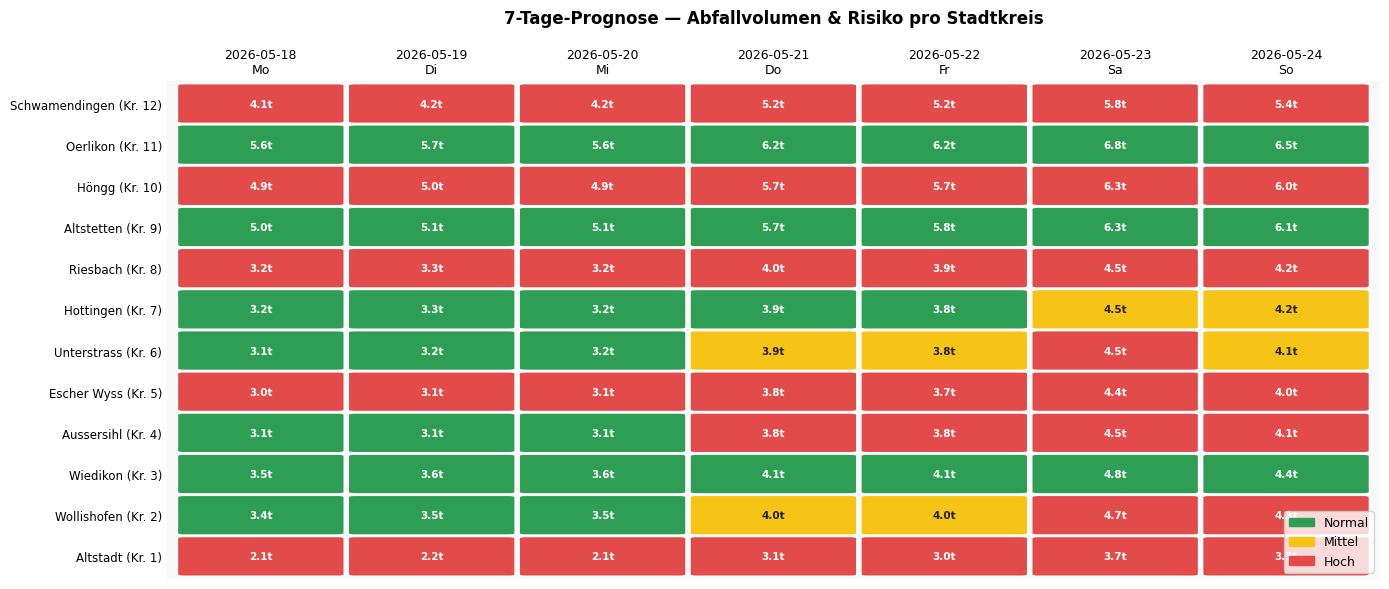

In [21]:
# 7-Tage-Heatmap: Stadtkreis × Tag als farbiges Raster.
# Jede Zelle zeigt Risikostufe (Farbe) und Tonnage (Text).
# Erstellt mit manuellen Rechtecken (FancyBboxPatch) statt eingebauter Heatmap, weil wir Text in die Zellen schreiben.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# RGB-Farben für Risikostufen (Werte zwischen 0 und 1)
# Folium nutzt Hex-Codes, matplotlib nutzt RGB-Tuples
RISIKO_RGB = {
    'normal': (0.18, 0.62, 0.33),   # Grün  – RGB(46, 158, 84)
    'mittel': (0.96, 0.77, 0.09),   # Gelb  – RGB(245, 196, 23)
    'hoch':   (0.89, 0.29, 0.29),   # Rot   – RGB(227, 74, 74)
}

# Achsenbeschriftungen aus predictions-Struktur extrahieren
# Datum + Wochentag auf zwei Zeilen: "2025-04-07\nMo"
tage   = [p['datum'] + '\n' + p['wochentag'] for p in predictions]

# Stadtkreis-Anzeigenamen aus erstem Tag (alle Tage haben gleiche Stadtkreise)
kreise = [b['anzeige'] for b in predictions[0]['stadtkreise']]

# Farbwerte und Tonnage in 2D-Listen organisieren
# farben[tag_index][stadtkreis_index] = RGB-Tuple
# werte[tag_index][stadtkreis_index] = float (Tonnen)
farben = []
werte  = []
for p in predictions:
    f_row, w_row = [], []
    for b in p['stadtkreise']:
        f_row.append(RISIKO_RGB[b['risikostufe']])
        w_row.append(b['prognose_t'])
    farben.append(f_row)
    werte.append(w_row)

fig, ax = plt.subplots(figsize=(14, 6))
ax.set_facecolor('#f8f8f8')  # Hintergrundfarbe der Plotfläche

# Zellen zeichnen: äussere Schleife = Tage (Spalten), innere = Stadtkreise (Zeilen)
for c, tag in enumerate(tage):
    for r, kreis in enumerate(kreise):
        farbe = farben[c][r] # RGB-Tuple dieser Zelle
        wert  = werte[c][r] # Tonnage dieser Zelle

        # Abgerundetes Rechteck (FancyBboxPatch) zeichnen
        # (c - 0.45, r - 0.45): linke untere Ecke des Rechtecks
        # 0.90, 0.90: Breite und Höhe (etwas kleiner als 1 -> kleiner Abstand)
        # boxstyle='round,pad=0.04': abgerundete Ecken
        rect = mpatches.FancyBboxPatch(
            (c - 0.45, r - 0.45), 0.90, 0.90,
            boxstyle='round,pad=0.04',
            facecolor=farbe,
            edgecolor='white',
            linewidth=1.5,
        )
        ax.add_patch(rect)

        # Textfarbe basierend auf Hintergrund-Helligkeit berechnen
        # Luminanz-Formel (wahrgenommene Helligkeit nach ITU-R BT.601)
        # 0.299 × R + 0.587 × G + 0.114 × B
        helligkeit = 0.299 * farbe[0] + 0.587 * farbe[1] + 0.114 * farbe[2]
        txt_farbe  = 'white' if helligkeit < 0.55 else '#222'

        # Text in Zellenmitte schreiben
        # ha='center', va='center': horizontal und vertikal zentriert
        ax.text(c, r, f'{wert:.1f}t',
                ha='center', va='center',
                fontsize=7.5, fontweight='bold',
                color=txt_farbe)

# Achsengrenzen und -beschriftungen setzen
ax.set_xlim(-0.55, len(tage) - 0.45)
ax.set_ylim(-0.55, len(kreise) - 0.45)

# X-Achse (Tage) oben anzeigen
ax.set_xticks(range(len(tage)))
ax.set_xticklabels(tage, fontsize=9)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')

# Y-Achse (Stadtkreise)
ax.set_yticks(range(len(kreise)))
ax.set_yticklabels(kreise, fontsize=8.5)

# Tick-Striche ausblenden und Rahmen entfernen
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

# Legende mit mpatches.Patch (farbige Rechtecke)
legende = [
    mpatches.Patch(color=RISIKO_RGB['normal'], label='Normal'),
    mpatches.Patch(color=RISIKO_RGB['mittel'], label='Mittel'),
    mpatches.Patch(color=RISIKO_RGB['hoch'],   label='Hoch'),
]
ax.legend(handles=legende, loc='lower right', frameon=True, fontsize=9)
ax.set_title('7-Tage-Prognose — Abfallvolumen & Risiko pro Stadtkreis',
             fontsize=12, fontweight='bold', pad=18)

plt.tight_layout()
plt.show()


---
## Fazit

Mit diesem Proof of Concept zeigen wir, dass sich tagesaktuelle Abfallprognosen aus öffentlichen Umweltdaten ableiten lassen. Wir haben fünf öffentliche APIs eingebunden, die alle kostenlos und ohne API-Key nutzbar sind:

* [Open-Meteo](https://open-meteo.com/) liefert das Wetter auf Basis von MeteoSchweiz-Daten, sowohl als Archiv als auch als 7-Tage-Forecast.
* Die [Luftqualitätsmessung der Stadt Zürich](https://data.stadt-zuerich.ch/dataset/ugz_luftschadstoffmessung_stundenwerte) gibt uns echte Stundenwerte für NO₂, PM10 und O₃.
* Die [Zürich Tourismus API](https://www.zuerich.com/) ergänzt um Veranstaltungsorte mit GPS-Koordinaten.
* Die [swisstopo-Geodaten](https://www.geo.admin.ch/de/programmierschnittstelle-api) helfen uns beim Reverse Geocoding von Koordinaten zu Stadtkreisen.
* Die [Stadtkreisgrenzen als GeoJSON](https://data.stadt-zuerich.ch/dataset/geo_stadtkreise) bilden die Grundlage der Risikokarte.

Auf dieser Datenbasis modellieren wir alle zwölf Stadtkreise von der Altstadt bis Schwamendingen und durchlaufen eine vollständige Datenpipeline: APIs abrufen, Daten transformieren, mit JOIN zusammenführen, Features bauen, das ML-Modell trainieren und das Ergebnis als JSON für die App exportieren. Die Korrelationsanalyse bestätigt unsere Annahmen: `ist_wochenende`, Temperatur, Saisonalität und Events korrelieren messbar mit der Abfallmenge, und wir interpretieren diese Zusammenhänge direkt im Notebook.

Wichtig ist uns ausserdem, dass jede Gewichtung im synthetischen Datensatz mit einer Quelle hinterlegt ist (Eurostat, BAFU, ERZ-Berichte). Aus den Prognosen leiten wir 12 verschiedene Hinweistypen ab, die je nach Kombination aus Risikostufe, Wetter, Eventstatus und Wochentag eine konkrete Handlungsempfehlung geben. Die fertigen JSON-Dateien `waste_predictions.json` und `district_stats.json` lassen sich direkt von der WebApp einlesen.

### Nächste Schritte für ein Produktivsystem

Damit aus dem PoC ein produktives System wird, sehen wir vier wesentliche Erweiterungen:

* **Echte Betriebsdaten** der ERZ ersetzen unsere synthetischen Abfallmengen, sobald ein Kunde wie ERZ Zürich seine Tourdaten einspielt.
* **Tägliche automatische Aktualisierung** über einen Cronjob (oder einen Task Scheduler unter Windows), sodass das Notebook beziehungsweise das Skript jeden Morgen die neuesten Werte abruft und die Prognose aktualisiert.
* **Feedback-Loop:** Tatsächliche und prognostizierte Mengen werden laufend verglichen, und das Modell wird mit den neuen Daten regelmässig nachtrainiert. Dieses Prinzip nennt man Continuous Learning.
* **Verkehrsbasierte Routenoptimierung** über die Google Maps Routes API: Echtzeit-Verkehrsdaten zur Minimierung von Fahrtdauer, Treibstoffverbrauch und CO₂-Emissionen, kombiniert mit der laufenden Position der Fahrzeuge für eine dynamische Routenanpassung im Betrieb.

Insgesamt zeigt der PoC, dass alle Bausteine zusammenspielen: APIs liefern reale Daten, das Modell findet Muster, und der Output ist app-tauglich. Der nächste logische Schritt wäre ein Pilot mit einem realen Kunden, der seine eigenen Betriebsdaten einbringt.
